# Saudi Customs Traffic AI Solution

1. Dataset Description
2. Import Libraries
3. Load Dataset
4. Data Exploration
5. Data Cleaning & Preprocessing
6. Exploratory Data Analysis (EDA)
7. Prepare Data for RAG
8. Create Documents
9. Create Embeddings
10. Build FAISS Vector Database
11. Retrieval
12. Question Answering with Gemini



## Dataset Description

The dataset contains hourly border traffic records collected from Saudi Arabia's land border ports during 2024 and 2025. Each record represents the number of vehicle movements at a specific border crossing, including the movement direction, date, and time.

### Dataset Information

- **Source:** Saudi Open Data Portal
- **Dataset Type:** Structured tabular dataset (CSV)
- **Domain:** Logistics and Transportation
- **Country:** Saudi Arabia
- **Time Period:** 2024–2025
- **Frequency:** Hourly records

### Dataset Features

| Feature | Data Type | Description |
|---------|----------|-------------|
| Port | Categorical | Border crossing name |
| Date | Date | Date of the record |
| Day | Categorical | Day of the week |
| Hour | Integer | Hour of the day |
| Direction | Categorical | Arrival or Departure |
| Movements | Integer | Number of vehicle movements |
| Year | Integer | Year |
| Month | Integer | Month |
| Quarter | Integer | Quarter of the year |

## Explore the Dataset

In [102]:
!pip install -q pandas numpy matplotlib plotly scikit-learn catboost

In [103]:
## Import Libraries
import os
import glob
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


In [104]:
from google.colab import files

uploaded = files.upload()

Saving Port traffic Q2 2025 csv.csv to Port traffic Q2 2025 csv (1).csv
Saving Port traffic Q4 2024 CSV.csv to Port traffic Q4 2024 CSV (1).csv
Saving Port traffic Q4 2025 csv.csv to Port traffic Q4 2025 csv (1).csv
Saving Port traffic Q1 2025 CSV.csv to Port traffic Q1 2025 CSV (1).csv
Saving Port traffic Q3 2025 csv.csv to Port traffic Q3 2025 csv (1).csv
Saving Port traffic Q3 2024 CSV.csv to Port traffic Q3 2024 CSV (1).csv
Saving Port traffic Q2 2024 cvs.csv to Port traffic Q2 2024 cvs (1).csv
Saving Port traffic Q1 2024 cvs.csv to Port traffic Q1 2024 cvs (1).csv


In [105]:
uploaded_files = list(uploaded.keys())

print("Uploaded files:")
for file_name in uploaded_files:
    print("-", file_name)

Uploaded files:
- Port traffic Q2 2025 csv (1).csv
- Port traffic Q4 2024 CSV (1).csv
- Port traffic Q4 2025 csv (1).csv
- Port traffic Q1 2025 CSV (1).csv
- Port traffic Q3 2025 csv (1).csv
- Port traffic Q3 2024 CSV (1).csv
- Port traffic Q2 2024 cvs (1).csv
- Port traffic Q1 2024 cvs (1).csv


In [106]:
dataframes = []

for file_name in uploaded_files:
    if file_name.lower().endswith(".csv"):
        try:
            temp_df = pd.read_csv(
                file_name,
                encoding="utf-8-sig"
            )

            temp_df["Source_File"] = file_name
            dataframes.append(temp_df)

            print(
                f"Loaded: {file_name} | "
                f"Rows: {len(temp_df):,} | "
                f"Columns: {len(temp_df.columns)}"
            )

        except UnicodeDecodeError:
            temp_df = pd.read_csv(
                file_name,
                encoding="cp1256"
            )

            temp_df["Source_File"] = file_name
            dataframes.append(temp_df)

            print(
                f"Loaded with Arabic encoding: {file_name} | "
                f"Rows: {len(temp_df):,}"
            )

Loaded: Port traffic Q2 2025 csv (1).csv | Rows: 36,429 | Columns: 7
Loaded: Port traffic Q4 2024 CSV (1).csv | Rows: 36,809 | Columns: 7
Loaded: Port traffic Q4 2025 csv (1).csv | Rows: 37,912 | Columns: 7
Loaded: Port traffic Q1 2025 CSV (1).csv | Rows: 35,708 | Columns: 7
Loaded: Port traffic Q3 2025 csv (1).csv | Rows: 38,097 | Columns: 7
Loaded: Port traffic Q3 2024 CSV (1).csv | Rows: 36,384 | Columns: 7
Loaded: Port traffic Q2 2024 cvs (1).csv | Rows: 34,966 | Columns: 7
Loaded: Port traffic Q1 2024 cvs (1).csv | Rows: 34,744 | Columns: 7


In [107]:
if len(dataframes) == 0:
    raise ValueError("No CSV files were loaded.")

df_raw = pd.concat(
    dataframes,
    ignore_index=True
)

print("Files merged successfully.")
print("Total rows:", f"{len(df_raw):,}")
print("Total columns:", len(df_raw.columns))

Files merged successfully.
Total rows: 291,049
Total columns: 10


In [108]:
display(df_raw.head())

,الجمرك,التاريخ,اليوم,الساعة,اتجاه الحركة,عدد الحركات,Source_File,تجاه الحركة,اسم المنفذ,الوجهه
0,البطحاء,2025-04-01,الثلاثاء,0,قدوم,27,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
1,البطحاء,2025-04-01,الثلاثاء,0,مغادرة,49,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
2,البطحاء,2025-04-01,الثلاثاء,1,قدوم,16,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
3,البطحاء,2025-04-01,الثلاثاء,1,مغادرة,25,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
4,البطحاء,2025-04-01,الثلاثاء,2,قدوم,21,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN


In [109]:
print("Column names:")
for column in df_raw.columns:
    print(repr(column))

Column names:
'الجمرك'
'التاريخ'
'اليوم'
'الساعة'
'اتجاه الحركة'
'عدد الحركات'
'Source_File'
'تجاه الحركة'
'اسم المنفذ'
'الوجهه'


In [110]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 291049 entries, 0 to 291048
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   الجمرك        184955 non-null  object
 1   التاريخ       291049 non-null  object
 2   اليوم         291049 non-null  object
 3   الساعة        291049 non-null  int64 
 4   اتجاه الحركة  147043 non-null  object
 5   عدد الحركات   291049 non-null  int64 
 6   Source_File   291049 non-null  object
 7   تجاه الحركة   37912 non-null   object
 8   اسم المنفذ    106094 non-null  object
 9   الوجهه        106094 non-null  object
dtypes: int64(2), object(8)
memory usage: 22.2+ MB


In [111]:
print("Dataset shape:", df_raw.shape)

print("\nMissing values:")
display(df_raw.isnull().sum().to_frame("Missing Values"))

print("\nDuplicate rows:")
print(df_raw.duplicated().sum())

Dataset shape: (291049, 10)

Missing values:


,Missing Values
الجمرك,106094
التاريخ,0
اليوم,0
الساعة,0
اتجاه الحركة,144006
عدد الحركات,0
Source_File,0
تجاه الحركة,253137
اسم المنفذ,184955
الوجهه,184955



Duplicate rows:
0


In [112]:
display(df_raw.head())

,الجمرك,التاريخ,اليوم,الساعة,اتجاه الحركة,عدد الحركات,Source_File,تجاه الحركة,اسم المنفذ,الوجهه
0,البطحاء,2025-04-01,الثلاثاء,0,قدوم,27,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
1,البطحاء,2025-04-01,الثلاثاء,0,مغادرة,49,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
2,البطحاء,2025-04-01,الثلاثاء,1,قدوم,16,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
3,البطحاء,2025-04-01,الثلاثاء,1,مغادرة,25,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN
4,البطحاء,2025-04-01,الثلاثاء,2,قدوم,21,Port traffic Q2 2025 csv (1).csv,NaN,NaN,NaN


In [113]:
print(df_raw.columns.tolist())

['الجمرك', 'التاريخ', 'اليوم', 'الساعة', 'اتجاه الحركة', 'عدد الحركات', 'Source_File', 'تجاه الحركة', 'اسم المنفذ', 'الوجهه']


## Data Cleaning

In [114]:
columns_to_check = [
    "الجمرك",
    "اسم المنفذ",
    "اتجاه الحركة",
    "تجاه الحركة",
    "الوجهه"
]

for column in columns_to_check:
    print("=" * 50)
    print("Column:", column)
    print("Non-null values:", df_raw[column].notna().sum())
    print("Sample values:")
    print(df_raw[column].dropna().astype(str).value_counts().head(10))
    print()

Column: الجمرك
Non-null values: 184955
Sample values:
الجمرك
البطحاء          21928
جسر الملك فهد    21885
سلوى             21740
الخفجي           20782
الربع الخالي     19508
الرقعي           18658
الحديثة          18637
الوديعة          15782
جديدة عرعر       12669
حالة عمار         8495
Name: count, dtype: int64

Column: اسم المنفذ
Non-null values: 106094
Sample values:
اسم المنفذ
البطحاء          13139
جسر الملك فهد    12994
سلوى             12565
الخفجي           12137
الربع الخالي     11317
الحديثة          10867
الرقعي            9910
الوديعة           7545
جديدة عرعر        7516
حالة عمار         4920
Name: count, dtype: int64

Column: اتجاه الحركة
Non-null values: 147043
Sample values:
اتجاه الحركة
مغادرة    74169
قدوم      72873
-             1
Name: count, dtype: int64

Column: تجاه الحركة
Non-null values: 37912
Sample values:
تجاه الحركة
مغادرة    19304
قدوم      18608
Name: count, dtype: int64

Column: الوجهه
Non-null values: 106094
Sample values:
الوجهه
مغادرة    53779
قد

In [115]:
df = df_raw.copy()


df["Port"] = (
    df["الجمرك"]
    .combine_first(df["اسم المنفذ"])
)


df["Direction"] = (
    df["اتجاه الحركة"]
    .combine_first(df["تجاه الحركة"])
    .combine_first(df["الوجهه"])
)


df["Direction"] = df["Direction"].replace("-", pd.NA)


df = df[
    [
        "Port",
        "التاريخ",
        "اليوم",
        "الساعة",
        "Direction",
        "عدد الحركات"
    ]
].copy()


df.columns = [
    "Port",
    "Date",
    "Day",
    "Hour",
    "Direction",
    "Movements"
]

display(df.head())

,Port,Date,Day,Hour,Direction,Movements
0,البطحاء,2025-04-01,الثلاثاء,0,قدوم,27
1,البطحاء,2025-04-01,الثلاثاء,0,مغادرة,49
2,البطحاء,2025-04-01,الثلاثاء,1,قدوم,16
3,البطحاء,2025-04-01,الثلاثاء,1,مغادرة,25
4,البطحاء,2025-04-01,الثلاثاء,2,قدوم,21


In [116]:
print(df.isnull().sum())

Port         0
Date         0
Day          0
Hour         0
Direction    1
Movements    0
dtype: int64


In [117]:
print(df["Direction"].value_counts(dropna=False))


Direction
مغادرة    147252
قدوم      143796
<NA>           1
Name: count, dtype: int64


In [118]:
# Remove the invalid direction value
df = df.dropna(subset=["Direction"]).copy()

# Convert the date column to datetime format
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce",
    dayfirst=True
)

# Convert hour column to numeric
df["Hour"] = pd.to_numeric(
    df["Hour"],
    errors="coerce"
)

# Convert movement count to numeric
df["Movements"] = pd.to_numeric(
    df["Movements"],
    errors="coerce"
)

# Remove rows with invalid values
df = df.dropna().copy()

# Convert numeric columns to integer
df["Hour"] = df["Hour"].astype(int)
df["Movements"] = df["Movements"].astype(int)

# Sort the dataset
df = df.sort_values(
    by=["Date", "Port", "Direction", "Hour"]
).reset_index(drop=True)


In [119]:
# Display dataset information
print(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 72272 entries, 0 to 72271
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Port       72272 non-null  object        
 1   Date       72272 non-null  datetime64[ns]
 2   Day        72272 non-null  object        
 3   Hour       72272 non-null  int64         
 4   Direction  72272 non-null  object        
 5   Movements  72272 non-null  int64         
dtypes: datetime64[ns](1), int64(2), object(3)
memory usage: 3.3+ MB
None


,Port,Date,Day,Hour,Direction,Movements
0,البطحاء,2024-01-10,الثلاثاء,0,قدوم,115
1,البطحاء,2024-01-10,الثلاثاء,1,قدوم,97
2,البطحاء,2024-01-10,الثلاثاء,2,قدوم,115
3,البطحاء,2024-01-10,الثلاثاء,3,قدوم,93
4,البطحاء,2024-01-10,الثلاثاء,4,قدوم,43


In [120]:
print("Dataset shape:", df.shape)

print("\nDate range:")
print(df["Date"].min())
print(df["Date"].max())

print("\nUnique ports:")
print(df["Port"].nunique())

print("\nPorts:")
print(df["Port"].value_counts())

print("\nDirections:")
print(df["Direction"].value_counts())

Dataset shape: (72272, 6)

Date range:
2024-01-10 00:00:00
2025-12-12 00:00:00

Unique ports:
11

Ports:
Port
البطحاء          8635
جسر الملك فهد    8615
سلوى             8530
الخفجي           8178
الربع الخالي     7650
الحديثة          7310
الرقعي           7235
الوديعة          6111
جديدة عرعر       4871
حالة عمار        3252
الدره            1885
Name: count, dtype: int64

Directions:
Direction
مغادرة    36446
قدوم      35826
Name: count, dtype: int64


In [121]:
print(df_raw.shape)

print(df_raw["التاريخ"].head(20))

(291049, 10)
0     2025-04-01
1     2025-04-01
2     2025-04-01
3     2025-04-01
4     2025-04-01
5     2025-04-01
6     2025-04-01
7     2025-04-01
8     2025-04-01
9     2025-04-01
10    2025-04-01
11    2025-04-01
12    2025-04-01
13    2025-04-01
14    2025-04-01
15    2025-04-01
16    2025-04-01
17    2025-04-01
18    2025-04-01
19    2025-04-01
Name: التاريخ, dtype: object


In [122]:
print(df_raw["التاريخ"].tail(20))

291029    03/31/2024 00:00:00
291030    03/31/2024 00:00:00
291031    03/31/2024 00:00:00
291032    03/31/2024 00:00:00
291033    03/31/2024 00:00:00
291034    03/31/2024 00:00:00
291035    03/31/2024 00:00:00
291036    03/31/2024 00:00:00
291037    03/31/2024 00:00:00
291038    03/31/2024 00:00:00
291039    03/31/2024 00:00:00
291040    03/31/2024 00:00:00
291041    03/31/2024 00:00:00
291042    03/31/2024 00:00:00
291043    03/31/2024 00:00:00
291044    03/31/2024 00:00:00
291045    03/31/2024 00:00:00
291046    03/31/2024 00:00:00
291047    03/31/2024 00:00:00
291048    03/31/2024 00:00:00
Name: التاريخ, dtype: object


In [123]:
# Create time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day_Of_Month"] = df["Date"].dt.day
df["Day_Of_Week"] = df["Date"].dt.day_name()

In [124]:
print("=" * 40)
print("Dataset Overview")
print("=" * 40)

print(f"Number of records: {len(df):,}")
print(f"Number of ports: {df['Port'].nunique()}")
print(f"Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")
print(f"Total movements: {df['Movements'].sum():,}")

Dataset Overview
Number of records: 72,272
Number of ports: 11
Date range: 2024-01-10 → 2025-12-12
Total movements: 1,857,742


In [125]:

missing = (
    df.isnull()
      .sum()
      .reset_index()
)

missing.columns = ["Column", "Missing Values"]

missing

,Column,Missing Values
0,Port,0
1,Date,0
2,Day,0
3,Hour,0
4,Direction,0
5,Movements,0
6,Year,0
7,Month,0
8,Month_Name,0
9,Quarter,0


In [126]:
# Recreate time features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day_Of_Month"] = df["Date"].dt.day
df["Day_Of_Week"] = df["Date"].dt.day_name()

In [127]:
print(df[["Date", "Month", "Day_Of_Month"]].head(20))

         Date  Month  Day_Of_Month
0  2024-01-10      1            10
1  2024-01-10      1            10
2  2024-01-10      1            10
3  2024-01-10      1            10
4  2024-01-10      1            10
5  2024-01-10      1            10
6  2024-01-10      1            10
7  2024-01-10      1            10
8  2024-01-10      1            10
9  2024-01-10      1            10
10 2024-01-10      1            10
11 2024-01-10      1            10
12 2024-01-10      1            10
13 2024-01-10      1            10
14 2024-01-10      1            10
15 2024-01-10      1            10
16 2024-01-10      1            10
17 2024-01-10      1            10
18 2024-01-10      1            10
19 2024-01-10      1            10


In [128]:
print(df[["Month", "Day_Of_Month", "Week"]].describe())

              Month  Day_Of_Month          Week
count  72272.000000  72272.000000  72272.000000
mean       6.507859      7.452319     25.569543
std        3.451680      3.580200     15.032906
min        1.000000      1.000000      1.000000
25%        4.000000      4.000000     14.000000
50%        7.000000      8.000000     27.000000
75%       10.000000     11.000000     40.000000
max       12.000000     12.000000     50.000000


In [129]:
print(df[["Date", "Month", "Day_Of_Month"]].head(20))

         Date  Month  Day_Of_Month
0  2024-01-10      1            10
1  2024-01-10      1            10
2  2024-01-10      1            10
3  2024-01-10      1            10
4  2024-01-10      1            10
5  2024-01-10      1            10
6  2024-01-10      1            10
7  2024-01-10      1            10
8  2024-01-10      1            10
9  2024-01-10      1            10
10 2024-01-10      1            10
11 2024-01-10      1            10
12 2024-01-10      1            10
13 2024-01-10      1            10
14 2024-01-10      1            10
15 2024-01-10      1            10
16 2024-01-10      1            10
17 2024-01-10      1            10
18 2024-01-10      1            10
19 2024-01-10      1            10


In [130]:
# Check the available day numbers
print(sorted(df["Day_Of_Month"].unique()))

[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


In [131]:
# Display random dates to verify date parsing
print(
    df[["Date", "Day"]]
    .drop_duplicates()
    .sample(30, random_state=42)
    .sort_values("Date")
)

            Date       Day
3628  2024-04-10    الجمعة
6032  2024-06-10     الاحد
6434  2024-06-11  الاربعاء
7222  2024-07-10   الاثنين
7638  2024-07-11    الخميس
9645  2024-09-10  الاربعاء
12039 2024-11-10    الجمعة
16704 2025-01-07  الثلاثاء
17934 2025-01-10  الاربعاء
20339 2025-02-04  الاربعاء
22328 2025-02-09  الثلاثاء
23991 2025-03-01    الجمعة
27199 2025-03-09  الاربعاء
27615 2025-03-10    الجمعة
31209 2025-04-07    الجمعة
37243 2025-05-10     الاحد
38468 2025-06-01   الاثنين
38868 2025-06-02    الخميس
45232 2025-07-06     السبت
47226 2025-07-11    الجمعة
48043 2025-08-01  الاربعاء
50031 2025-08-06     الاحد
56902 2025-09-11     الاحد
57311 2025-09-12  الثلاثاء
58129 2025-10-02   الاثنين
59348 2025-10-05     السبت
61351 2025-10-10    الجمعة
63773 2025-11-04    الجمعة
69025 2025-12-05   الاثنين
69430 2025-12-06    الخميس


In [132]:
print(df_raw["التاريخ"].head(20).tolist())

['2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01', '2025-04-01']


In [133]:
# Convert date correctly
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

In [134]:
# Create time-based features
df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Month_Name"] = df["Date"].dt.month_name()
df["Quarter"] = df["Date"].dt.quarter
df["Week"] = df["Date"].dt.isocalendar().week.astype(int)
df["Day_Of_Month"] = df["Date"].dt.day
df["Day_Of_Week"] = df["Date"].dt.day_name()

In [135]:
print(df[["Date", "Month", "Day_Of_Month"]].head())
print(df["Day_Of_Month"].describe())

        Date  Month  Day_Of_Month
0 2024-01-10      1            10
1 2024-01-10      1            10
2 2024-01-10      1            10
3 2024-01-10      1            10
4 2024-01-10      1            10
count    72272.000000
mean         7.452319
std          3.580200
min          1.000000
25%          4.000000
50%          8.000000
75%         11.000000
max         12.000000
Name: Day_Of_Month, dtype: float64


In [136]:
# Check available day numbers
print("Unique days:")
print(sorted(df["Date"].dt.day.unique()))

# Check available months
print("\nUnique months:")
print(sorted(df["Date"].dt.month.unique()))

# Number of unique dates
print("\nUnique dates:", df["Date"].nunique())

Unique days:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Unique months:
[np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]

Unique dates: 180


In [137]:
# Number of records for each date
daily_counts = (
    df.groupby("Date")
      .size()
      .reset_index(name="Records")
)

display(daily_counts.head(30))
display(daily_counts.tail(30))

,Date,Records
0,2024-01-10,412
1,2024-01-11,401
2,2024-01-12,409
3,2024-02-10,405
4,2024-02-11,389
5,2024-02-12,398
6,2024-03-10,408
7,2024-03-11,409
8,2024-03-12,397
9,2024-04-10,386


,Date,Records
150,2025-10-07,407
151,2025-10-08,422
152,2025-10-09,416
153,2025-10-10,405
154,2025-10-11,415
155,2025-10-12,411
156,2025-11-01,386
157,2025-11-02,410
158,2025-11-03,395
159,2025-11-04,397


In [138]:
print(df.columns.tolist())

['Port', 'Date', 'Day', 'Hour', 'Direction', 'Movements', 'Year', 'Month', 'Month_Name', 'Quarter', 'Week', 'Day_Of_Month', 'Day_Of_Week']


In [139]:
# Convert date column
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

# Total traffic by port
traffic_by_port = (
    df.groupby("Port", as_index=False)["Movements"]
      .sum()
      .sort_values("Movements", ascending=False)
)

highest_port = traffic_by_port.iloc[0]
lowest_port = traffic_by_port.iloc[-1]

# Total traffic by month
df["Year_Month"] = df["Date"].dt.to_period("M").astype(str)

traffic_by_month = (
    df.groupby("Year_Month", as_index=False)["Movements"]
      .sum()
      .sort_values("Movements", ascending=False)
)

highest_month = traffic_by_month.iloc[0]

# Total traffic by hour
traffic_by_hour = (
    df.groupby("Hour", as_index=False)["Movements"]
      .sum()
      .sort_values("Movements", ascending=False)
)

peak_hour = traffic_by_hour.iloc[0]

print("=" * 50)
print(
    "Highest traffic port:",
    highest_port["Port"],
    "-",
    f'{highest_port["Movements"]:,.0f}'
)

print(
    "Lowest traffic port:",
    lowest_port["Port"],
    "-",
    f'{lowest_port["Movements"]:,.0f}'
)

print(
    "Highest traffic month:",
    highest_month["Year_Month"],
    "-",
    f'{highest_month["Movements"]:,.0f}'
)

print(
    "Peak traffic hour:",
    f'{int(peak_hour["Hour"]):02d}:00',
    "-",
    f'{peak_hour["Movements"]:,.0f}'
)
print("=" * 50)

Highest traffic port: البطحاء - 757,722
Lowest traffic port: الدره - 10,112
Highest traffic month: 2025-10 - 127,686
Peak traffic hour: 16:00 - 105,570


# Exploratory Data Analysis (EDA)

In [140]:
# Question:
# Which border crossing handles the highest traffic volume?

port_summary = (
    df.groupby("Port", as_index=False)["Movements"]
      .sum()
      .sort_values("Movements", ascending=True)
)

# Convert values to compact labels such as 758K
port_summary["Label"] = port_summary["Movements"].apply(
    lambda x: f"{x / 1_000_000:.1f}M"
    if x >= 1_000_000
    else f"{x / 1_000:.0f}K"
)

fig = px.bar(
    port_summary,
    x="Movements",
    y="Port",
    orientation="h",
    text="Label",
    title="Border Traffic Distribution Across Saudi Ports",
    color_discrete_sequence=["#2E7D32"]
)

fig.update_traces(
    textposition="outside",
    textfont=dict(
        size=13,
        color="#1B4332"
    ),
    marker=dict(
        line=dict(
            color="#1B5E20",
            width=0.7
        )
    ),
    hovertemplate=(
        "<b>%{y}</b><br>"
        "Total movements: %{x:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=600,
    showlegend=False,
    title=dict(
        text="Border Traffic Distribution Across Saudi Ports",
        x=0.5,
        font=dict(
            size=22,
            color="#1B4332"
        )
    ),
    xaxis=dict(
        title="Total Movements",
        tickformat="~s",
        gridcolor="#E8F5E9",
        zeroline=False
    ),
    yaxis=dict(
        title="Border Port"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(
        l=130,
        r=90,
        t=90,
        b=60
    )
)

fig.show()

##### Key Insight:
#####  This chart identifies the ports with the highest movement volumes.
#####  Ports with significantly higher traffic should be prioritized for
#####  congestion management, staffing, and predictive resource planning.

In [141]:
# Question:
# At what time of day does border traffic peak?


hourly_summary = (
    df.groupby("Hour", as_index=False)["Movements"]
      .mean()
)

fig = px.line(
    hourly_summary,
    x="Hour",
    y="Movements",
    markers=True,
    title="Average Border Traffic by Hour"
)

fig.update_traces(
    line=dict(
        color="#2E7D32",
        width=4
    ),
    marker=dict(
        color="#43A047",
        size=9,
        line=dict(
            color="#1B5E20",
            width=1
        )
    ),
    hovertemplate=(
        "<b>%{x}:00</b><br>"
        "Average Movements: %{y:,.1f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=550,
    title=dict(
        text="Average Border Traffic by Hour",
        x=0.5,
        font=dict(
            size=22,
            color="#1B4332"
        )
    ),
    xaxis=dict(
        title="Hour of Day",
        tickmode="linear",
        dtick=1,
        gridcolor="#E8F5E9"
    ),
    yaxis=dict(
        title="Average Movements",
        gridcolor="#E8F5E9"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(
        l=80,
        r=40,
        t=90,
        b=60
    )
)

fig.show()


#### Key Insight:
#### Traffic is not evenly distributed throughout the day.
#### Peak hours indicate when additional staffing and operational
#### capacity may be required to reduce waiting times.

In [142]:
# Question:
# Is border traffic driven more by arrivals or departures?


direction_summary = (
    df.groupby("Direction", as_index=False)["Movements"]
      .sum()
)

fig = px.pie(
    direction_summary,
    names="Direction",
    values="Movements",
    hole=0.55,
    title="Arrival vs Departure Traffic Distribution",
    color="Direction",
    color_discrete_sequence=[
        "#2E7D32",  # Dark green
        "#66BB6A"   # Medium green
    ]
)

fig.update_traces(
    textinfo="label+percent",
    textfont=dict(
        size=14
    ),
    marker=dict(
        line=dict(
            color="white",
            width=3
        )
    ),
    hovertemplate=(
        "<b>%{label}</b><br>"
        "Total Movements: %{value:,.0f}<br>"
        "Share: %{percent}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=520,
    title=dict(
        text="Arrival vs Departure Traffic Distribution",
        x=0.5,
        font=dict(
            size=22,
            color="#1B4332"
        )
    ),
    legend=dict(
        title="Traffic Direction",
        orientation="h",
        yanchor="bottom",
        y=-0.15,
        xanchor="center",
        x=0.5
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(
        l=40,
        r=40,
        t=90,
        b=80
    )
)

fig.show()

#### Key Insight:
#### Comparing arrivals and departures shows whether operational
#### pressure is concentrated in one traffic direction.
#### Resources can then be allocated based on actual demand rather
#### than being distributed equally.

In [143]:
# Question:
# How does border traffic change across different months?


monthly_summary = (
    df.groupby("Month_Name", as_index=False)["Movements"]
      .mean()
)

# Preserve calendar order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_summary["Month_Name"] = pd.Categorical(
    monthly_summary["Month_Name"],
    categories=month_order,
    ordered=True
)

monthly_summary = monthly_summary.sort_values("Month_Name")

fig = px.line(
    monthly_summary,
    x="Month_Name",
    y="Movements",
    markers=True,
    title="Average Border Traffic by Month"
)

fig.update_traces(
    line=dict(
        color="#2E7D32",
        width=4
    ),
    marker=dict(
        size=9,
        color="#43A047",
        line=dict(
            color="#1B5E20",
            width=1
        )
    ),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Average Movements: %{y:,.1f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=550,
    title=dict(
        text="Average Border Traffic by Month",
        x=0.5,
        font=dict(
            size=22,
            color="#1B4332"
        )
    ),
    xaxis=dict(
        title="Month",
        gridcolor="#E8F5E9"
    ),
    yaxis=dict(
        title="Average Movements",
        gridcolor="#E8F5E9"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(
        l=80,
        r=40,
        t=90,
        b=60
    )
)

fig.show()

### Key Insight

- Border traffic changes across the year, indicating seasonal demand patterns.
- Some months consistently experience higher traffic volumes than others.
- These seasonal trends can support long-term operational planning and resource allocation.
- Monthly patterns also provide valuable information for forecasting future border traffic.

In [144]:
# Question:
# Which observed days recorded the highest border traffic?


daily_summary = (
    df.groupby("Date", as_index=False)["Movements"]
      .sum()
      .sort_values("Movements", ascending=False)
      .head(10)
)

daily_summary["Date"] = daily_summary["Date"].dt.strftime("%d-%b-%Y")

fig = px.bar(
    daily_summary,
    x="Date",
    y="Movements",
    text="Movements",
    title="Top 10 Highest-Traffic Observed Days",
    color_discrete_sequence=["#2E7D32"]
)

fig.update_traces(
    texttemplate="%{text:,.0f}",
    textposition="outside",
    marker=dict(
        line=dict(
            color="#1B5E20",
            width=0.8
        )
    ),
    hovertemplate=(
        "<b>%{x}</b><br>"
        "Total Movements: %{y:,.0f}"
        "<extra></extra>"
    )
)

fig.update_layout(
    template="plotly_white",
    height=550,
    title=dict(
        text="Top 10 Highest-Traffic Observed Days",
        x=0.5,
        font=dict(
            size=22,
            color="#1B4332"
        )
    ),
    xaxis=dict(
        title="Observed Date",
        gridcolor="#E8F5E9"
    ),
    yaxis=dict(
        title="Total Movements",
        gridcolor="#E8F5E9"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(
        l=80,
        r=40,
        t=90,
        b=80
    )
)

fig.show()

### Key Insight

- A small number of observed days account for exceptionally high traffic volumes.
- These peaks may indicate holidays, seasonal travel, or other high-demand periods.
- Recognizing these peak days enables authorities to prepare resources before congestion occurs.
- These observations reinforce the need for predictive models rather than reactive planning.

In [145]:
# Question:
# Which ports experience the highest traffic at different hours
# of the day?


heatmap_data = (
    df.pivot_table(
        index="Port",
        columns="Hour",
        values="Movements",
        aggfunc="mean"
    )
)

fig = px.imshow(
    heatmap_data,
    color_continuous_scale=[
        "#F1F8E9",
        "#C8E6C9",
        "#81C784",
        "#43A047",
        "#2E7D32"
    ],
    aspect="auto",
    labels=dict(
        x="Hour of Day",
        y="Border Port",
        color="Average\nMovements"
    ),
    title="Average Border Traffic by Port and Hour"
)

fig.update_layout(
    template="plotly_white",
    height=650,
    title=dict(
        text="Average Border Traffic by Port and Hour",
        x=0.5,
        font=dict(
            size=22,
            color="#1B4332"
        )
    ),
    xaxis=dict(
        title="Hour of Day",
        tickmode="linear",
        dtick=1
    ),
    yaxis=dict(
        title="Border Port"
    ),
    coloraxis_colorbar=dict(
        title="Average<br>Movements"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(
        l=130,
        r=40,
        t=90,
        b=60
    )
)

fig.show()

### Key Insight

- Traffic intensity varies significantly across both ports and hours.
- Some border crossings consistently experience higher demand during specific time periods.
- These operational hotspots indicate where additional staffing and resources may be required.
- The identified patterns provide strong evidence for using AI-based forecasting to anticipate congestion before it occurs.

In [146]:
# Question:
# How does border traffic vary across ports and months?


heatmap_month = (
    df.pivot_table(
        index="Port",
        columns="Month_Name",
        values="Movements",
        aggfunc="mean"
    )
)

# Keep months in calendar order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

heatmap_month = heatmap_month.reindex(columns=month_order)

fig = px.imshow(
    heatmap_month,
    aspect="auto",
    color_continuous_scale=[
        "#F1F8E9",
        "#C8E6C9",
        "#81C784",
        "#43A047",
        "#2E7D32"
    ],
    labels=dict(
        x="Month",
        y="Border Port",
        color="Average\nMovements"
    ),
    title="Average Border Traffic by Port and Month"
)

fig.update_layout(
    template="plotly_white",
    height=650,
    title=dict(
        text="Average Border Traffic by Port and Month",
        x=0.5,
        font=dict(
            size=22,
            color="#1B4332"
        )
    ),
    xaxis=dict(
        title="Month"
    ),
    yaxis=dict(
        title="Border Port"
    ),
    coloraxis_colorbar=dict(
        title="Average<br>Movements"
    ),
    plot_bgcolor="white",
    paper_bgcolor="white",
    margin=dict(
        l=130,
        r=40,
        t=90,
        b=60
    )
)

fig.show()

### Key Insight

- Seasonal traffic patterns differ across border crossings.
- Some ports experience higher demand during specific months, while others remain relatively stable.
- These differences indicate that operational planning should be tailored to each border crossing rather than applying a single strategy nationwide.
- The combination of temporal and spatial patterns provides strong evidence for building an AI forecasting model to predict future traffic.

Total traffic increased in 2025 compared to 2024, indicating overall growth in border and port movements.

# Traffic Forecasting

## Why Forecast Border Traffic?

The exploratory analysis revealed that border traffic varies significantly across ports, hours, and months. Rather than reacting to congestion after it occurs, forecasting enables authorities to anticipate traffic demand and allocate resources proactively.

The objective of this model is to predict future border movements using historical traffic patterns and temporal features.

In [147]:
!pip install prophet

In [148]:
df["Date"] = pd.to_datetime(
    df["Date"],
    errors="coerce"
)

df["Movements"] = pd.to_numeric(
    df["Movements"],
    errors="coerce"
)

df = df.dropna(
    subset=["Date", "Movements"]
).copy()

forecast_df = (
    df.groupby("Date", as_index=False)
      .agg({"Movements": "sum"})
      .sort_values("Date")
      .reset_index(drop=True)
)

print("Forecast data shape:", forecast_df.shape)
print("Start date:", forecast_df["Date"].min())
print("End date:", forecast_df["Date"].max())

display(forecast_df.head())
display(forecast_df.tail())

Forecast data shape: (180, 2)
Start date: 2024-01-10 00:00:00
End date: 2025-12-12 00:00:00


,Date,Movements
0,2024-01-10,10838
1,2024-01-11,10741
2,2024-01-12,10821
3,2024-02-10,10806
4,2024-02-11,9339


,Date,Movements
175,2025-12-08,10335
176,2025-12-09,11307
177,2025-12-10,11079
178,2025-12-11,11863
179,2025-12-12,11296


In [149]:
prophet_df = forecast_df.rename(
    columns={
        "Date": "ds",
        "Movements": "y"
    }
).copy()

prophet_df["ds"] = pd.to_datetime(
    prophet_df["ds"],
    errors="coerce"
)

prophet_df["y"] = pd.to_numeric(
    prophet_df["y"],
    errors="coerce"
)

prophet_df = (
    prophet_df
    .dropna(subset=["ds", "y"])
    .sort_values("ds")
    .drop_duplicates(subset=["ds"])
    .reset_index(drop=True)
)

print("Prophet data shape:", prophet_df.shape)
print("Start date:", prophet_df["ds"].min())
print("End date:", prophet_df["ds"].max())

display(prophet_df.head())
display(prophet_df.tail())

Prophet data shape: (180, 2)
Start date: 2024-01-10 00:00:00
End date: 2025-12-12 00:00:00


,ds,y
0,2024-01-10,10838
1,2024-01-11,10741
2,2024-01-12,10821
3,2024-02-10,10806
4,2024-02-11,9339


,ds,y
175,2025-12-08,10335
176,2025-12-09,11307
177,2025-12-10,11079
178,2025-12-11,11863
179,2025-12-12,11296


In [150]:
complete_dates = pd.date_range(
    start=prophet_df["ds"].min(),
    end=prophet_df["ds"].max(),
    freq="D"
)

missing_dates = complete_dates.difference(
    prophet_df["ds"]
)

print("Expected number of days:", len(complete_dates))
print("Available number of days:", len(prophet_df))
print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("First missing dates:")
    print(missing_dates[:10])

Expected number of days: 703
Available number of days: 180
Missing dates: 523
First missing dates:
DatetimeIndex(['2024-01-13', '2024-01-14', '2024-01-15', '2024-01-16',
               '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20',
               '2024-01-21', '2024-01-22'],
              dtype='datetime64[ns]', freq=None)


In [151]:
complete_dates = pd.date_range(
    start=prophet_df["ds"].min(),
    end=prophet_df["ds"].max(),
    freq="D"
)

missing_dates = complete_dates.difference(
    prophet_df["ds"]
)

print("Expected number of days:", len(complete_dates))
print("Available number of days:", len(prophet_df))
print("Missing dates:", len(missing_dates))

if len(missing_dates) > 0:
    print("First missing dates:")
    print(missing_dates[:10])

Expected number of days: 703
Available number of days: 180
Missing dates: 523
First missing dates:
DatetimeIndex(['2024-01-13', '2024-01-14', '2024-01-15', '2024-01-16',
               '2024-01-17', '2024-01-18', '2024-01-19', '2024-01-20',
               '2024-01-21', '2024-01-22'],
              dtype='datetime64[ns]', freq=None)


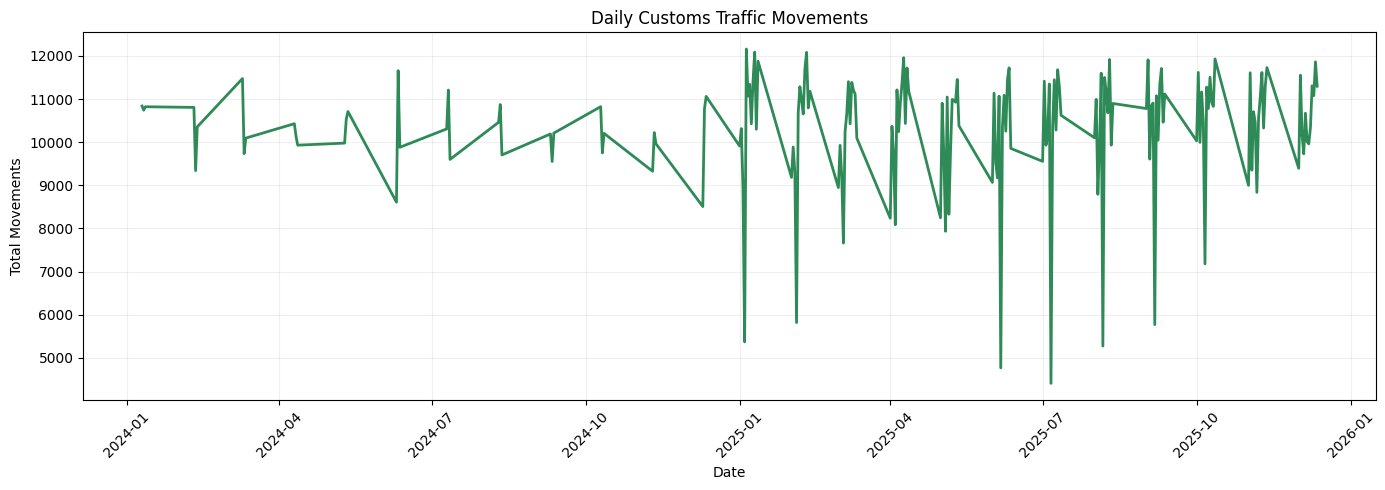

In [152]:
plt.figure(figsize=(14, 5))

plt.plot(
    prophet_df["ds"],
    prophet_df["y"],
    color="#2E8B57",
    linewidth=2
)

plt.title("Daily Customs Traffic Movements")
plt.xlabel("Date")
plt.ylabel("Total Movements")
plt.xticks(rotation=45)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

In [153]:
split_index = int(
    len(prophet_df) * 0.80
)

train_df = prophet_df.iloc[
    :split_index
].copy()

test_df = prophet_df.iloc[
    split_index:
].copy()

print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

print(
    "Training period:",
    train_df["ds"].min(),
    "to",
    train_df["ds"].max()
)

print(
    "Testing period:",
    test_df["ds"].min(),
    "to",
    test_df["ds"].max()
)

Training rows: 144
Testing rows: 36
Training period: 2024-01-10 00:00:00 to 2025-09-12 00:00:00
Testing period: 2025-10-01 00:00:00 to 2025-12-12 00:00:00


In [154]:
from prophet import Prophet

evaluation_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

evaluation_model.fit(
    train_df
)

In [155]:
test_future = test_df[
    ["ds"]
].copy()

test_forecast = evaluation_model.predict(
    test_future
)

test_results = test_df.merge(
    test_forecast[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ],
    on="ds",
    how="left"
)

display(test_results.head())

,ds,y,yhat,yhat_lower,yhat_upper
0,2025-10-01,10031,10299.108065,7612.016349,13015.566787
1,2025-10-02,11618,10624.297909,7916.734521,13279.905253
2,2025-10-03,9995,10228.185009,7405.597045,13092.980550
3,2025-10-04,11163,9975.147032,7384.720535,12603.146509
4,2025-10-05,10463,10251.700099,7495.725261,12753.741030


In [156]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)
mae = mean_absolute_error(
    test_results["y"],
    test_results["yhat"]
)

rmse = np.sqrt(
    mean_squared_error(
        test_results["y"],
        test_results["yhat"]
    )
)

mape = mean_absolute_percentage_error(
    test_results["y"],
    test_results["yhat"]
) * 100

print(f"MAE: {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")

MAE: 979.05
RMSE: 1167.98
MAPE: 9.44%


The forecasting model achieved a Mean Absolute Percentage Error (MAPE) of 9.44%, indicating that the predicted traffic volumes were, on average, within approximately 9.4% of the actual observations.

The model also achieved a Mean Absolute Error (MAE) of 979.05 movements and a Root Mean Squared Error (RMSE) of 1167.98 movements.

These results demonstrate that the Prophet model successfully captured the overall traffic trend and can provide reliable forecasts to support proactive planning and resource allocation across Saudi border customs.

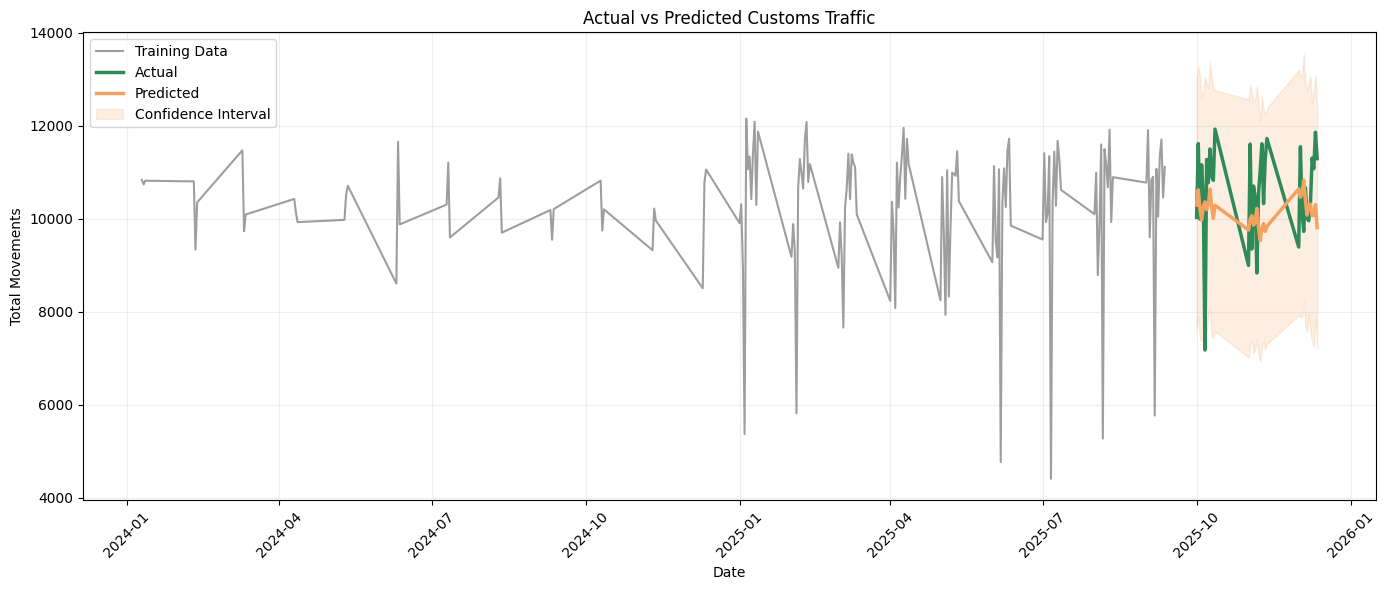

In [157]:
plt.figure(figsize=(14, 6))

plt.plot(
    train_df["ds"],
    train_df["y"],
    label="Training Data",
    color="#9E9E9E",
    linewidth=1.5
)

plt.plot(
    test_results["ds"],
    test_results["y"],
    label="Actual",
    color="#2E8B57",
    linewidth=2.5
)

plt.plot(
    test_results["ds"],
    test_results["yhat"],
    label="Predicted",
    color="#F4A261",
    linewidth=2.5
)

plt.fill_between(
    test_results["ds"],
    test_results["yhat_lower"],
    test_results["yhat_upper"],
    color="#F4A261",
    alpha=0.18,
    label="Confidence Interval"
)

plt.title("Actual vs Predicted Customs Traffic")
plt.xlabel("Date")
plt.ylabel("Total Movements")
plt.legend()
plt.grid(alpha=0.2)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [158]:
final_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,
    interval_width=0.95
)

final_model.fit(
    prophet_df
)

print("Final model trained successfully.")

Final model trained successfully.


In [159]:
future_90_days = final_model.make_future_dataframe(
    periods=90,
    freq="D",
    include_history=True
)

forecast_90_days = final_model.predict(
    future_90_days
)

display(
    forecast_90_days[
        [
            "ds",
            "yhat",
            "yhat_lower",
            "yhat_upper"
        ]
    ].tail()
)

,ds,yhat,yhat_lower,yhat_upper
265,2026-03-08,10473.978316,7971.071569,12940.683116
266,2026-03-09,10134.509727,7537.763008,12769.579085
267,2026-03-10,10319.571395,7898.989006,12958.394475
268,2026-03-11,10273.717441,7567.186761,12912.287540
269,2026-03-12,10482.476976,7884.524112,13015.142119


In [160]:
last_historical_date = prophet_df[
    "ds"
].max()

forecast_end_date = pd.Timestamp(
    "2026-12-31"
)

future_days = (
    forecast_end_date -
    last_historical_date
).days

print(
    "Last historical date:",
    last_historical_date
)

print(
    "Forecast end date:",
    forecast_end_date
)

print(
    "Number of future days:",
    future_days
)

if future_days <= 0:
    raise ValueError(
        "The historical data already reaches or exceeds 2026-12-31."
    )

future_until_2026 = final_model.make_future_dataframe(
    periods=future_days,
    freq="D",
    include_history=True
)

forecast_until_2026 = final_model.predict(
    future_until_2026
)

Last historical date: 2025-12-12 00:00:00
Forecast end date: 2026-12-31 00:00:00
Number of future days: 384


In [161]:
customs_forecast = forecast_until_2026[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].copy()

customs_forecast = customs_forecast[
    customs_forecast["ds"].between(
        "2026-01-01",
        "2026-12-31"
    )
].copy()

customs_forecast[
    [
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
] = customs_forecast[
    [
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].clip(lower=0)

customs_forecast = customs_forecast.reset_index(
    drop=True
)

print(
    "2026 forecast rows:",
    len(customs_forecast)
)

print(
    "Forecast start:",
    customs_forecast["ds"].min()
)

print(
    "Forecast end:",
    customs_forecast["ds"].max()
)

display(
    customs_forecast.head()
)

display(
    customs_forecast.tail()
)

2026 forecast rows: 365
Forecast start: 2026-01-01 00:00:00
Forecast end: 2026-12-31 00:00:00


,ds,yhat,yhat_lower,yhat_upper
0,2026-01-01,10493.423857,7907.790052,12974.615529
1,2026-01-02,10234.649307,7639.601332,12856.546982
2,2026-01-03,10019.220821,7433.302732,12610.891465
3,2026-01-04,10439.859906,7677.916611,13249.067851
4,2026-01-05,10225.592958,7726.507721,12747.083618


,ds,yhat,yhat_lower,yhat_upper
360,2026-12-27,10186.528427,7637.777276,12883.879518
361,2026-12-28,9926.163595,7399.189916,12472.801472
362,2026-12-29,10195.209289,7667.739077,12809.682217
363,2026-12-30,10236.758812,7542.579545,12929.794389
364,2026-12-31,10534.816843,8172.842715,13249.001115


In [162]:
customs_forecast.to_csv(
    "customs_forecast.csv",
    index=False
)

print(
    "customs_forecast.csv saved successfully."
)

customs_forecast.csv saved successfully.


In [163]:
saved_forecast = pd.read_csv(
    "customs_forecast.csv"
)

saved_forecast["ds"] = pd.to_datetime(
    saved_forecast["ds"],
    errors="coerce"
)

print(
    "Saved file shape:",
    saved_forecast.shape
)

print(
    "Saved file columns:",
    saved_forecast.columns.tolist()
)

print(
    "Minimum date:",
    saved_forecast["ds"].min()
)

print(
    "Maximum date:",
    saved_forecast["ds"].max()
)

print(
    "2026 rows:",
    saved_forecast["ds"].between(
        "2026-01-01",
        "2026-12-31"
    ).sum()
)

display(
    saved_forecast.head()
)

Saved file shape: (365, 4)
Saved file columns: ['ds', 'yhat', 'yhat_lower', 'yhat_upper']
Minimum date: 2026-01-01 00:00:00
Maximum date: 2026-12-31 00:00:00
2026 rows: 365


,ds,yhat,yhat_lower,yhat_upper
0,2026-01-01,10493.423857,7907.790052,12974.615529
1,2026-01-02,10234.649307,7639.601332,12856.546982
2,2026-01-03,10019.220821,7433.302732,12610.891465
3,2026-01-04,10439.859906,7677.916611,13249.067851
4,2026-01-05,10225.592958,7726.507721,12747.083618


# Agentic RAG

In [164]:
         !pip install -q \
    langchain \
    langchain-community \
    langchain-huggingface \
    langchain-google-genai \
    sentence-transformers \
    faiss-cpu

In [165]:
from langchain_core.documents import Document
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_community.vectorstores import FAISS

import re
import os

In [166]:
# Daily total movements
daily_total = (
    df.groupby("Date", as_index=False)["Movements"]
      .sum()
      .rename(columns={"Movements": "Total_Movements"})
)

# Busiest port for each day
daily_port = (
    df.groupby(["Date", "Port"], as_index=False)["Movements"]
      .sum()
)

top_port = (
    daily_port
    .sort_values(
        ["Date", "Movements"],
        ascending=[True, False]
    )
    .drop_duplicates("Date")
    .rename(columns={
        "Port": "Top_Port",
        "Movements": "Top_Port_Movements"
    })
)

# Peak hour for each day
daily_hour = (
    df.groupby(["Date", "Hour"], as_index=False)["Movements"]
      .sum()
)

peak_hour = (
    daily_hour
    .sort_values(
        ["Date", "Movements"],
        ascending=[True, False]
    )
    .drop_duplicates("Date")
    .rename(columns={
        "Hour": "Peak_Hour",
        "Movements": "Peak_Hour_Movements"
    })
)

# Dominant direction for each day
daily_direction = (
    df.groupby(["Date", "Direction"], as_index=False)["Movements"]
      .sum()
)

top_direction = (
    daily_direction
    .sort_values(
        ["Date", "Movements"],
        ascending=[True, False]
    )
    .drop_duplicates("Date")
    .rename(columns={
        "Direction": "Dominant_Direction",
        "Movements": "Direction_Movements"
    })
)

# Final daily summary
daily_summary = (
    daily_total
    .merge(
        top_port[
            ["Date", "Top_Port", "Top_Port_Movements"]
        ],
        on="Date",
        how="left"
    )
    .merge(
        peak_hour[
            ["Date", "Peak_Hour", "Peak_Hour_Movements"]
        ],
        on="Date",
        how="left"
    )
    .merge(
        top_direction[
            [
                "Date",
                "Dominant_Direction",
                "Direction_Movements"
            ]
        ],
        on="Date",
        how="left"
    )
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Daily summary shape:", daily_summary.shape)
print(daily_summary.columns.tolist())

daily_summary.head()

Daily summary shape: (180, 8)
['Date', 'Total_Movements', 'Top_Port', 'Top_Port_Movements', 'Peak_Hour', 'Peak_Hour_Movements', 'Dominant_Direction', 'Direction_Movements']


,Date,Total_Movements,Top_Port,Top_Port_Movements,Peak_Hour,Peak_Hour_Movements,Dominant_Direction,Direction_Movements
0,2024-01-10,10838,البطحاء,4348,17,647,قدوم,6149
1,2024-01-11,10741,البطحاء,4575,9,660,قدوم,6161
2,2024-01-12,10821,البطحاء,4540,13,656,قدوم,6075
3,2024-02-10,10806,البطحاء,4478,9,636,قدوم,6113
4,2024-02-11,9339,البطحاء,3445,19,580,قدوم,5901


In [167]:
daily_documents = []

for _, row in daily_summary.iterrows():

    date_value = pd.to_datetime(row["Date"])

    content = (
        f"Daily customs traffic summary for "
        f"{date_value.strftime('%Y-%m-%d')}. "
        f"Total movements across all Saudi customs ports were "
        f"{row['Total_Movements']:,.0f}. "
        f"The busiest port was {row['Top_Port']} with "
        f"{row['Top_Port_Movements']:,.0f} movements. "
        f"The peak traffic hour was "
        f"{int(row['Peak_Hour']):02d}:00 with "
        f"{row['Peak_Hour_Movements']:,.0f} movements. "
        f"The dominant direction was "
        f"{row['Dominant_Direction']} with "
        f"{row['Direction_Movements']:,.0f} movements."
    )

    metadata = {
        "document_type": "daily_summary",
        "date": date_value.strftime("%Y-%m-%d"),
        "year_month": date_value.strftime("%Y-%m"),
        "top_port": str(row["Top_Port"]),
        "peak_hour": int(row["Peak_Hour"]),
        "total_movements": float(row["Total_Movements"]),
        "dominant_direction": str(
            row["Dominant_Direction"]
        )
    }

    daily_documents.append({
        "content": content,
        "metadata": metadata
    })

print("Daily documents:", len(daily_documents))
print(daily_documents[0])

Daily documents: 180
{'content': 'Daily customs traffic summary for 2024-01-10. Total movements across all Saudi customs ports were 10,838. The busiest port was البطحاء with 4,348 movements. The peak traffic hour was 17:00 with 647 movements. The dominant direction was قدوم with 6,149 movements.', 'metadata': {'document_type': 'daily_summary', 'date': '2024-01-10', 'year_month': '2024-01', 'top_port': 'البطحاء', 'peak_hour': 17, 'total_movements': 10838.0, 'dominant_direction': 'قدوم'}}


In [168]:
df["Year_Month"] = (
    pd.to_datetime(df["Date"])
      .dt.to_period("M")
      .astype(str)
)

# Total movements by month and port
monthly_port = (
    df.groupby(
        ["Year_Month", "Port"],
        as_index=False
    )["Movements"]
    .sum()
    .rename(columns={
        "Movements": "Total_Movements"
    })
)

# Peak hour by month and port
monthly_hour = (
    df.groupby(
        ["Year_Month", "Port", "Hour"],
        as_index=False
    )["Movements"]
    .sum()
)

monthly_peak_hour = (
    monthly_hour
    .sort_values(
        ["Year_Month", "Port", "Movements"],
        ascending=[True, True, False]
    )
    .drop_duplicates(
        ["Year_Month", "Port"]
    )
    .rename(columns={
        "Hour": "Peak_Hour",
        "Movements": "Peak_Hour_Movements"
    })
)

# Dominant direction by month and port
monthly_direction = (
    df.groupby(
        ["Year_Month", "Port", "Direction"],
        as_index=False
    )["Movements"]
    .sum()
)

monthly_top_direction = (
    monthly_direction
    .sort_values(
        ["Year_Month", "Port", "Movements"],
        ascending=[True, True, False]
    )
    .drop_duplicates(
        ["Year_Month", "Port"]
    )
    .rename(columns={
        "Direction": "Dominant_Direction",
        "Movements": "Direction_Movements"
    })
)

# Final monthly summary
monthly_summary = (
    monthly_port
    .merge(
        monthly_peak_hour[
            [
                "Year_Month",
                "Port",
                "Peak_Hour",
                "Peak_Hour_Movements"
            ]
        ],
        on=["Year_Month", "Port"],
        how="left"
    )
    .merge(
        monthly_top_direction[
            [
                "Year_Month",
                "Port",
                "Dominant_Direction",
                "Direction_Movements"
            ]
        ],
        on=["Year_Month", "Port"],
        how="left"
    )
    .sort_values(["Year_Month", "Port"])
    .reset_index(drop=True)
)

print("Monthly summary shape:", monthly_summary.shape)
print(monthly_summary.columns.tolist())

monthly_summary.head()

Monthly summary shape: (264, 7)
['Year_Month', 'Port', 'Total_Movements', 'Peak_Hour', 'Peak_Hour_Movements', 'Dominant_Direction', 'Direction_Movements']


,Year_Month,Port,Total_Movements,Peak_Hour,Peak_Hour_Movements,Dominant_Direction,Direction_Movements
0,2024-01,البطحاء,13463,13,759,قدوم,8438
1,2024-01,الحديثة,3905,17,381,مغادرة,2016
2,2024-01,الخفجي,2741,18,187,مغادرة,1451
3,2024-01,الدره,162,9,42,مغادرة,121
4,2024-01,الربع الخالي,1641,15,115,قدوم,951


In [169]:
monthly_documents = []

for _, row in monthly_summary.iterrows():

    year_month = str(row["Year_Month"])

    content = (
        f"Monthly customs traffic summary for "
        f"{row['Port']} during {year_month}. "
        f"The port recorded "
        f"{row['Total_Movements']:,.0f} total movements. "
        f"The peak traffic hour was "
        f"{int(row['Peak_Hour']):02d}:00 with "
        f"{row['Peak_Hour_Movements']:,.0f} movements. "
        f"The dominant direction was "
        f"{row['Dominant_Direction']} with "
        f"{row['Direction_Movements']:,.0f} movements."
    )

    metadata = {
        "document_type": "monthly_port_summary",
        "year_month": year_month,
        "port": str(row["Port"]),
        "peak_hour": int(row["Peak_Hour"]),
        "peak_hour_movements": float(
            row["Peak_Hour_Movements"]
        ),
        "total_movements": float(
            row["Total_Movements"]
        ),
        "dominant_direction": str(
            row["Dominant_Direction"]
        ),
        "direction_movements": float(
            row["Direction_Movements"]
        )
    }

    monthly_documents.append({
        "content": content,
        "metadata": metadata
    })

print("Monthly documents:", len(monthly_documents))
print(monthly_documents[0])

Monthly documents: 264
{'content': 'Monthly customs traffic summary for البطحاء during 2024-01. The port recorded 13,463 total movements. The peak traffic hour was 13:00 with 759 movements. The dominant direction was قدوم with 8,438 movements.', 'metadata': {'document_type': 'monthly_port_summary', 'year_month': '2024-01', 'port': 'البطحاء', 'peak_hour': 13, 'peak_hour_movements': 759.0, 'total_movements': 13463.0, 'dominant_direction': 'قدوم', 'direction_movements': 8438.0}}


In [170]:
daily_summary = (
    daily_summary
    .sort_values("Date")
    .reset_index(drop=True)
    .copy()
)

daily_summary["Rolling_Average"] = (
    daily_summary["Total_Movements"]
    .rolling(
        window=7,
        min_periods=3
    )
    .mean()
)

daily_summary["Deviation_Percent"] = (
    (
        daily_summary["Total_Movements"]
        - daily_summary["Rolling_Average"]
    )
    / daily_summary["Rolling_Average"]
) * 100

anomalies = (
    daily_summary[
        daily_summary["Deviation_Percent"].abs() >= 20
    ]
    .copy()
    .reset_index(drop=True)
)

print("Anomalies:", len(anomalies))

anomalies[
    [
        "Date",
        "Total_Movements",
        "Rolling_Average",
        "Deviation_Percent",
        "Top_Port",
        "Peak_Hour"
    ]
].head()

Anomalies: 12


,Date,Total_Movements,Rolling_Average,Deviation_Percent,Top_Port,Peak_Hour
0,2025-01-04,5369,9268.142857,-42.070379,البطحاء,16
1,2025-01-05,12159,9789.857143,24.199974,البطحاء,18
2,2025-02-04,5817,9780.428571,-40.524079,البطحاء,21
3,2025-03-04,7660,9971.428571,-23.180516,البطحاء,20
4,2025-04-01,8236,10552.571429,-21.952672,البطحاء,20


In [171]:
anomaly_documents = []

for _, row in anomalies.iterrows():

    date_value = pd.to_datetime(row["Date"])
    deviation = float(row["Deviation_Percent"])

    if deviation > 0:
        trend = "higher than normal"
        anomaly_direction = "increase"
    else:
        trend = "lower than normal"
        anomaly_direction = "decrease"

    content = (
        f"An unusual traffic pattern was detected on "
        f"{date_value.strftime('%Y-%m-%d')}. "
        f"Total traffic reached "
        f"{row['Total_Movements']:,.0f} movements, "
        f"which was {abs(deviation):.1f}% "
        f"{trend} compared with the rolling average. "
        f"The busiest port was {row['Top_Port']}, "
        f"and the peak traffic hour was "
        f"{int(row['Peak_Hour']):02d}:00."
    )

    metadata = {
        "document_type": "anomaly",
        "date": date_value.strftime("%Y-%m-%d"),
        "year_month": date_value.strftime("%Y-%m"),
        "deviation_percent": deviation,
        "anomaly_direction": anomaly_direction,
        "total_movements": float(
            row["Total_Movements"]
        ),
        "top_port": str(row["Top_Port"]),
        "peak_hour": int(row["Peak_Hour"])
    }

    anomaly_documents.append({
        "content": content,
        "metadata": metadata
    })

print("Anomaly documents:", len(anomaly_documents))

if anomaly_documents:
    print(anomaly_documents[0])

Anomaly documents: 12
{'content': 'An unusual traffic pattern was detected on 2025-01-04. Total traffic reached 5,369 movements, which was 42.1% lower than normal compared with the rolling average. The busiest port was البطحاء, and the peak traffic hour was 16:00.', 'metadata': {'document_type': 'anomaly', 'date': '2025-01-04', 'year_month': '2025-01', 'deviation_percent': -42.070379333199746, 'anomaly_direction': 'decrease', 'total_movements': 5369.0, 'top_port': 'البطحاء', 'peak_hour': 16}}


In [172]:
rag_documents = (
    daily_documents
    + monthly_documents
    + anomaly_documents
)

print(f"Daily Documents   : {len(daily_documents)}")
print(f"Monthly Documents : {len(monthly_documents)}")
print(f"Anomaly Documents : {len(anomaly_documents)}")
print("-" * 40)
print(f"Total Documents   : {len(rag_documents)}")

Daily Documents   : 180
Monthly Documents : 264
Anomaly Documents : 12
----------------------------------------
Total Documents   : 456


In [173]:
from langchain_core.documents import Document

langchain_documents = []

for document in rag_documents:

    langchain_document = Document(
        page_content=document["content"],
        metadata=document["metadata"]
    )

    langchain_documents.append(langchain_document)


print(f"LangChain Documents: {len(langchain_documents)}")

if langchain_documents:
    print("\nSample Content:")
    print(langchain_documents[0].page_content)

    print("\nSample Metadata:")
    print(langchain_documents[0].metadata)

LangChain Documents: 456

Sample Content:
Daily customs traffic summary for 2024-01-10. Total movements across all Saudi customs ports were 10,838. The busiest port was البطحاء with 4,348 movements. The peak traffic hour was 17:00 with 647 movements. The dominant direction was قدوم with 6,149 movements.

Sample Metadata:
{'document_type': 'daily_summary', 'date': '2024-01-10', 'year_month': '2024-01', 'top_port': 'البطحاء', 'peak_hour': 17, 'total_movements': 10838.0, 'dominant_direction': 'قدوم'}


In [174]:
from langchain_huggingface import HuggingFaceEmbeddings

embedding_model = HuggingFaceEmbeddings(
    model_name=(
        "sentence-transformers/"
        "paraphrase-multilingual-MiniLM-L12-v2"
    ),
    model_kwargs={
        "device": "cpu"
    },
    encode_kwargs={
        "normalize_embeddings": True
    }
)

print("Embedding model loaded successfully.")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Embedding model loaded successfully.


In [175]:
from langchain_community.vectorstores import FAISS

vector_db = FAISS.from_documents(
    documents=langchain_documents,
    embedding=embedding_model
)

print("FAISS vector database created successfully.")
print(f"Stored documents: {len(langchain_documents)}")

FAISS vector database created successfully.
Stored documents: 456


In [176]:
FAISS_PATH = "/content/saudi_customs_faiss"

vector_db.save_local(FAISS_PATH)

print(f"FAISS database saved to: {FAISS_PATH}")

FAISS database saved to: /content/saudi_customs_faiss


In [177]:
vector_db = FAISS.load_local(
    folder_path=FAISS_PATH,
    embeddings=embedding_model,
    allow_dangerous_deserialization=True
)

print("FAISS vector database loaded successfully.")

FAISS vector database loaded successfully.


In [178]:
retriever = vector_db.as_retriever(
    search_type="mmr",
    search_kwargs={
        "k": 12,
        "fetch_k": 40,
        "lambda_mult": 0.7
    }
)

print("Retriever is ready.")

Retriever is ready.


In [179]:
MONTHS = {
    # English
    "january": "01",
    "february": "02",
    "march": "03",
    "april": "04",
    "may": "05",
    "june": "06",
    "july": "07",
    "august": "08",
    "september": "09",
    "october": "10",
    "november": "11",
    "december": "12",

    # Arabic
    "يناير": "01",
    "فبراير": "02",
    "مارس": "03",
    "أبريل": "04",
    "ابريل": "04",
    "مايو": "05",
    "يونيو": "06",
    "يوليو": "07",
    "أغسطس": "08",
    "اغسطس": "08",
    "سبتمبر": "09",
    "أكتوبر": "10",
    "اكتوبر": "10",
    "نوفمبر": "11",
    "ديسمبر": "12"
}

In [180]:
import re


def extract_year_month(question):

    normalized_question = question.lower().strip()

    # Example: 2025-01
    direct_match = re.search(
        r"\b(20\d{2})[-/](0?[1-9]|1[0-2])\b",
        normalized_question
    )

    if direct_match:
        year = direct_match.group(1)
        month = direct_match.group(2).zfill(2)

        return f"{year}-{month}"

    # Example: January 2025
    year_match = re.search(
        r"\b(20\d{2})\b",
        normalized_question
    )

    if not year_match:
        return None

    year = year_match.group(1)

    for month_name, month_number in MONTHS.items():

        if month_name in normalized_question:
            return f"{year}-{month_number}"

    return None

In [181]:
AVAILABLE_PORTS = sorted(
    {
        str(document.metadata["port"])
        for document in langchain_documents
        if document.metadata.get("port")
    },
    key=len,
    reverse=True
)


def extract_ports(question):

    normalized_question = question.lower()
    selected_ports = []

    for port in AVAILABLE_PORTS:

        if port.lower() in normalized_question:
            selected_ports.append(port)

    return selected_ports

In [182]:
QUESTION_KEYWORDS = {
    "comparison": [
        "compare",
        "comparison",
        "versus",
        " vs ",
        "between",
        "difference",
        "قارن",
        "مقارنة",
        "الفرق",
        "بين"
    ],

    "highest": [
        "highest",
        "most",
        "maximum",
        "busiest",
        "top",
        "أعلى",
        "أكثر",
        "الأكثر",
        "اعلى",
        "ازدحام"
    ],

    "lowest": [
        "lowest",
        "least",
        "minimum",
        "أقل",
        "الأقل",
        "اقل"
    ],

    "anomaly": [
        "anomaly",
        "anomalies",
        "unusual",
        "abnormal",
        "unexpected",
        "outlier",
        "spike",
        "drop",
        "شذوذ",
        "غير طبيعي",
        "غير طبيعية",
        "غير معتاد",
        "غير معتادة",
        "ارتفاع مفاجئ",
        "انخفاض مفاجئ"
    ]
}


def detect_question_type(question):

    normalized_question = f" {question.lower().strip()} "

    for question_type, keywords in QUESTION_KEYWORDS.items():

        if any(
            keyword in normalized_question
            for keyword in keywords
        ):
            return question_type

    return "general"

In [183]:
test_questions = [
    "Compare الربع الخالي and الدره during January 2025.",
    "Which customs port had the highest traffic in January 2025?",
    "Were there any unusual traffic patterns in January 2025?",
    "قارن بين البطحاء والحديثة خلال يناير 2025"
]


for question in test_questions:


    print("Question:", question)
    print("Year Month:", extract_year_month(question))
    print("Ports:", extract_ports(question))
    print("Question Type:", detect_question_type(question))

Question: Compare الربع الخالي and الدره during January 2025.
Year Month: 2025-01
Ports: ['الربع الخالي', 'الدره']
Question Type: comparison
Question: Which customs port had the highest traffic in January 2025?
Year Month: 2025-01
Ports: []
Question Type: highest
Question: Were there any unusual traffic patterns in January 2025?
Year Month: 2025-01
Ports: []
Question Type: anomaly
Question: قارن بين البطحاء والحديثة خلال يناير 2025
Year Month: 2025-01
Ports: ['الحديثة', 'البطحاء']
Question Type: comparison


In [184]:
def filter_documents(
    documents,
    year_month=None,
    ports=None,
    document_type=None
):

    filtered_documents = []

    for document in documents:

        metadata = document.metadata or {}

        if document_type is not None:

            if metadata.get("document_type") != document_type:
                continue

        if year_month is not None:

            if metadata.get("year_month") != year_month:
                continue

        if ports:

            if metadata.get("port") not in ports:
                continue

        filtered_documents.append(document)

    return filtered_documents

In [185]:
def retrieve_documents(question):

    question_type = detect_question_type(question)
    year_month = extract_year_month(question)
    ports = extract_ports(question)

    # Highest / lowest traffic
    if question_type in ["highest", "lowest"]:

        ranking_documents = filter_documents(
            documents=langchain_documents,
            year_month=year_month,
            document_type="monthly_port_summary"
        )

        ranking_documents = sorted(
            ranking_documents,
            key=lambda document: float(
                document.metadata.get("total_movements", 0)
            ),
            reverse=(question_type == "highest")
        )

        # Return only the correct highest/lowest document
        return ranking_documents[:1]

    # Anomaly questions
    if question_type == "anomaly":

        anomaly_results = filter_documents(
            documents=langchain_documents,
            year_month=year_month,
            document_type="anomaly"
        )

        return sorted(
            anomaly_results,
            key=lambda document: document.metadata.get("date", "")
        )

    # Comparison questions
    if question_type == "comparison" and ports:

        return filter_documents(
            documents=langchain_documents,
            year_month=year_month,
            ports=ports,
            document_type="monthly_port_summary"
        )

    # General semantic retrieval
    retrieved_documents = retriever.invoke(question)

    return filter_documents(
        documents=retrieved_documents,
        year_month=year_month,
        ports=ports if ports else None
    )

In [186]:
retrieval_tests = [
    "Compare الربع الخالي and الدره during January 2025.",
    "Which customs port had the highest traffic during January 2025?",
    "Which customs port had the lowest traffic during January 2025?",
    "Were there any unusual traffic patterns during January 2025?"
]


for question in retrieval_tests:

    documents = retrieve_documents(question)

    print("Question:", question)
    print("Type:", detect_question_type(question))
    print("Year Month:", extract_year_month(question))
    print("Ports:", extract_ports(question))
    print("Retrieved Documents:", len(documents))

    for document in documents[:3]:
        print(document.metadata)
        print(document.page_content[:300])

Question: Compare الربع الخالي and الدره during January 2025.
Type: comparison
Year Month: 2025-01
Ports: ['الربع الخالي', 'الدره']
Retrieved Documents: 2
{'document_type': 'monthly_port_summary', 'year_month': '2025-01', 'port': 'الدره', 'peak_hour': 9, 'peak_hour_movements': 108.0, 'total_movements': 636.0, 'dominant_direction': 'مغادرة', 'direction_movements': 438.0}
Monthly customs traffic summary for الدره during 2025-01. The port recorded 636 total movements. The peak traffic hour was 09:00 with 108 movements. The dominant direction was مغادرة with 438 movements.
{'document_type': 'monthly_port_summary', 'year_month': '2025-01', 'port': 'الربع الخالي', 'peak_hour': 9, 'peak_hour_movements': 392.0, 'total_movements': 5545.0, 'dominant_direction': 'قدوم', 'direction_movements': 2924.0}
Monthly customs traffic summary for الربع الخالي during 2025-01. The port recorded 5,545 total movements. The peak traffic hour was 09:00 with 392 movements. The dominant direction was قدوم with 2,92

In [187]:
from langchain_google_genai import ChatGoogleGenerativeAI
import os
from google.colab import userdata

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
print("Gemini key loaded:", bool(os.environ.get("GEMINI_API_KEY")))

llm = ChatGoogleGenerativeAI(
    model="gemini-3.5-flash-lite",
    google_api_key=os.environ.get("GEMINI_API_KEY"),
    temperature=0,
    max_retries=2
)

print("Gemini model is ready.")

Gemini key loaded: True
Gemini model is ready.


In [188]:
system_prompt = """
You are an AI assistant specialized in Saudi customs traffic analysis.

Use ONLY the provided context to answer the question.

Rules:

1. Do not invent any values or facts.
2. If the answer is not available in the context, say:
   "The requested information is not available in the provided data."
3. Keep the answer clear, concise, and factual.
4. Do not mention vector databases, embeddings, retrieval, documents,
   LangChain, FAISS, or internal implementation details.
5. Always place proper spaces between Arabic and English words.
6. Use the word "منفذ" instead of "ميناء" for land customs ports.
7. Detect the language of the user's question before answering.
8. If the question is written mainly in English, answer entirely in English,
   except for official Arabic port names and direction values from the data.
9. If the question is written mainly in Arabic, answer entirely in Arabic.
10. Do not translate Arabic port names unless an official English name
    is available in the context.

For comparison questions:
- Compare total movements.
- Calculate the difference in total movements.
- Mention the peak hour for each port.
- Mention the dominant direction for each port.
- Clearly state which port had higher traffic.

For highest or lowest traffic questions:
- Identify the correct port.
- Mention total movements.
- Mention peak hour and dominant direction if available.
- Do not create rankings beyond what the question requests.

For anomaly questions:
- State whether unusual traffic patterns were detected.
- Mention every relevant date in the requested period.
- Mention total movements.
- Mention whether traffic increased or decreased.
- Mention the deviation percentage.
- Mention the busiest port and peak hour if available.
- If there are no anomaly records, clearly state that no unusual
  traffic patterns were detected in the requested period.
"""

In [189]:
def extract_response_text(response):

    content = response.content


    if isinstance(content, str):
        return content.strip()


    if isinstance(content, list):

        text_parts = []

        for item in content:

            if isinstance(item, dict):

                if item.get("type") == "text":
                    text_parts.append(
                        str(item.get("text", ""))
                    )

            elif isinstance(item, str):
                text_parts.append(item)

        return "\n".join(text_parts).strip()

    return str(content)

In [190]:
import re


def is_arabic_question(text):
    arabic_letters = re.findall(r"[\u0600-\u06FF]", text)
    english_letters = re.findall(r"[A-Za-z]", text)

    return len(arabic_letters) > len(english_letters)


def format_ranking_answer(question, document, question_type):

    metadata = document.metadata

    port = metadata.get("port")
    total_movements = metadata.get("total_movements")
    peak_hour = metadata.get("peak_hour")
    peak_hour_movements = metadata.get("peak_hour_movements")
    dominant_direction = metadata.get("dominant_direction")
    direction_movements = metadata.get("direction_movements")
    year_month = metadata.get("year_month")

    # Format numbers
    total_movements = f"{float(total_movements):,.0f}"

    if peak_hour_movements is not None:
        peak_hour_movements = f"{float(peak_hour_movements):,.0f}"

    if direction_movements is not None:
        direction_movements = f"{float(direction_movements):,.0f}"

    if peak_hour is not None:
        peak_hour = f"{int(peak_hour):02d}:00"

    # Convert year-month
    month_names_ar = {
        "01": "يناير",
        "02": "فبراير",
        "03": "مارس",
        "04": "أبريل",
        "05": "مايو",
        "06": "يونيو",
        "07": "يوليو",
        "08": "أغسطس",
        "09": "سبتمبر",
        "10": "أكتوبر",
        "11": "نوفمبر",
        "12": "ديسمبر"
    }

    month_names_en = {
        "01": "January",
        "02": "February",
        "03": "March",
        "04": "April",
        "05": "May",
        "06": "June",
        "07": "July",
        "08": "August",
        "09": "September",
        "10": "October",
        "11": "November",
        "12": "December"
    }

    year, month = year_month.split("-")

    if is_arabic_question(question):

        ranking_word = "أعلى" if question_type == "highest" else "أقل"
        month_name = month_names_ar.get(month, month)

        answer = (
            f"منفذ {port} هو المنفذ الذي سجل {ranking_word} حركة مرور "
            f"خلال شهر {month_name} {year}، بإجمالي {total_movements} حركة."
        )

        if peak_hour is not None:
            answer += f"\n\n- ساعة الذروة: {peak_hour}"

            if peak_hour_movements is not None:
                answer += f" بعدد {peak_hour_movements} حركة"

        if dominant_direction is not None:
            answer += f"\n- الاتجاه السائد: {dominant_direction}"

            if direction_movements is not None:
                answer += f" بعدد {direction_movements} حركة"

        return answer

    else:

        ranking_word = "highest" if question_type == "highest" else "lowest"
        month_name = month_names_en.get(month, month)

        answer = (
            f"The customs port with the {ranking_word} traffic during "
            f"{month_name} {year} was {port}, with a total of "
            f"{total_movements} movements."
        )

        if peak_hour is not None:
            answer += f"\n\n- Peak traffic hour: {peak_hour}"

            if peak_hour_movements is not None:
                answer += f" with {peak_hour_movements} movements"

        if dominant_direction is not None:
            answer += f"\n- Dominant direction: {dominant_direction}"

            if direction_movements is not None:
                answer += f" with {direction_movements} movements"

        return answer


def ask_customs_rag(question):

    documents = retrieve_documents(question)
    question_type = detect_question_type(question)

    if not documents:

        if is_arabic_question(question):
            return "المعلومات المطلوبة غير متوفرة في البيانات.", []

        return (
            "The requested information is not available in the provided data.",
            []
        )

    # Answer highest/lowest questions directly from metadata
    if question_type in ["highest", "lowest"]:

        answer = format_ranking_answer(
            question=question,
            document=documents[0],
            question_type=question_type
        )

        return answer, documents

    # Build context for comparison, anomaly and general questions
    context_parts = []

    for document in documents:

        metadata_text = "\n".join(
            f"{key}: {value}"
            for key, value in document.metadata.items()
        )

        context_parts.append(
            f"""
Document content:
{document.page_content}

Document metadata:
{metadata_text}
""".strip()
        )

    context = "\n\n---\n\n".join(context_parts)

    prompt = f"""
{system_prompt}

Context:
{context}

User Question:
{question}

Answer:
"""

    try:

        response = llm.invoke(prompt)
        answer = extract_response_text(response)

        return answer, documents

    except Exception as e:

        error = str(e)

        if (
            "429" in error
            or "RESOURCE_EXHAUSTED" in error
            or "quota" in error.lower()
        ):

            if is_arabic_question(question):
                return (
                    "تم تجاوز الحد المسموح لاستخدام Gemini API. "
                    "حاولي مرة أخرى لاحقًا.",
                    documents
                )

            return (
                "Gemini API quota exceeded. Please try again later.",
                documents
            )

        return f"Error: {error}", documents

In [191]:
question = (
    "Compare الربع الخالي and الدره "
    "during January 2025."
)

answer, source_documents = ask_customs_rag(question)

print("Question:")
print(question)

print("\nAnswer:")
print(answer)

print("\nRetrieved Documents:")
print(len(source_documents))

Question:
Compare الربع الخالي and الدره during January 2025.

Answer:
Error: Illegal header value b'AQ.Ab8RN6IoUT6ATZTitRqiujsD8ft6EIy0JTZT93yNMn8kbH1cgA\r\nAQ.Ab8RN6IoUT6ATZTitRqiujsD8ft6EIy0JTZT93yNMn8kbH1cgA'

Retrieved Documents:
2


In [192]:
question = (
    "Were there any unusual traffic patterns "
    "during January 2025?"
)

answer, source_documents = ask_customs_rag(question)

print(answer)
print("Retrieved Documents:", len(source_documents))

Error: Illegal header value b'AQ.Ab8RN6IoUT6ATZTitRqiujsD8ft6EIy0JTZT93yNMn8kbH1cgA\r\nAQ.Ab8RN6IoUT6ATZTitRqiujsD8ft6EIy0JTZT93yNMn8kbH1cgA'
Retrieved Documents: 2


In [193]:
question = (
    "Which customs port had the lowest traffic "
    "during January 2025?"
)

answer, source_documents = ask_customs_rag(question)

print("Question:")
print(question)

print("\nAnswer:")
print(answer)

print("\nRetrieved Documents:")
print(len(source_documents))

print("\nSource Metadata:")
for doc in source_documents:
    print(doc.metadata)

Question:
Which customs port had the lowest traffic during January 2025?

Answer:
The customs port with the lowest traffic during January 2025 was الدره, with a total of 636 movements.

- Peak traffic hour: 09:00 with 108 movements
- Dominant direction: مغادرة with 438 movements

Retrieved Documents:
1

Source Metadata:
{'document_type': 'monthly_port_summary', 'year_month': '2025-01', 'port': 'الدره', 'peak_hour': 9, 'peak_hour_movements': 108.0, 'total_movements': 636.0, 'dominant_direction': 'مغادرة', 'direction_movements': 438.0}


# Streamlit

In [194]:
!pip install -q streamlit pyngrok

In [195]:
from google.colab import userdata
import os

os.environ["GEMINI_API_KEY"] = userdata.get("GEMINI_API_KEY")
print("Gemini key loaded:", bool(os.environ.get("GEMINI_API_KEY")))

Gemini key loaded: True


In [196]:
%%writefile app.py
import os
import re
import time
from typing import Any

import pandas as pd
import plotly.graph_objects as go
import streamlit as st

from langchain_community.vectorstores import FAISS
from langchain_core.messages import HumanMessage, SystemMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langchain_huggingface import HuggingFaceEmbeddings

APP_DIR = os.path.dirname(os.path.abspath(__file__))
FAISS_PATH = os.path.join(APP_DIR, "saudi_customs_faiss")
FORECAST_PATH = os.path.join(APP_DIR, "customs_forecast.csv")


st.set_page_config(
    page_title="Saudi Customs Traffic AI Solution",
    page_icon="",
    layout="wide",
    initial_sidebar_state="collapsed"
)


st.html(
    """
    <style>
    :root {
        --background: #06110d;
        --sidebar: #081912;
        --card: #0d2119;
        --card-light: #123126;
        --card-hover: #173d2e;
        --border: #245c43;
        --green: #22c55e;
        --green-light: #4ade80;
        --green-dark: #15803d;
        --white: #ffffff;
        --muted: #b7cabf;
    }

    html,
    body,
    .stApp {
        background-color: var(--background);
        color: var(--white);
    }

    .stApp {
        background:
            radial-gradient(
                circle at top right,
                rgba(34, 197, 94, 0.08),
                transparent 35%
            ),
            var(--background);
    }

    [data-testid="stHeader"] {
        background: transparent;
    }

    [data-testid="stSidebar"],
    [data-testid="collapsedControl"] {
        display: none !important;
    }

    .block-container {
        max-width: 1180px;
        padding-top: 2rem;
        padding-bottom: 4rem;
    }

    h1,
    h2,
    h3,
    h4,
    h5,
    h6,
    p,
    label,
    li {
        color: var(--white) !important;
    }

    .main-title {
        color: var(--white);
        font-size: 40px;
        font-weight: 800;
        line-height: 1.2;
        margin: 8px 0 6px 0;
    }

    .subtitle {
        color: var(--muted);
        font-size: 16px;
        margin-bottom: 26px;
    }

    .section-title {
        color: var(--green-light);
        font-size: 25px;
        font-weight: 750;
        margin: 12px 0 14px 0;
    }

    .info-card {
        background-color: var(--card);
        border: 1px solid var(--border);
        border-left: 5px solid var(--green);
        border-radius: 14px;
        padding: 18px;
        color: var(--white);
        margin-bottom: 18px;
    }

    .info-card strong {
        color: var(--green-light) !important;
    }

    [data-testid="stMetric"] {
        background-color: var(--card);
        border: 1px solid var(--border);
        border-radius: 14px;
        padding: 18px;
        min-height: 125px;
    }

    [data-testid="stMetricLabel"] p {
        color: var(--muted) !important;
        font-weight: 600;
    }

    [data-testid="stMetricValue"] {
        color: var(--green-light) !important;
        font-weight: 800;
    }

    [data-testid="stMetricDelta"] {
        color: var(--white) !important;
    }

    .stSelectbox label,
    .stTextInput label,
    .stMultiSelect label,
    .stDateInput label {
        color: var(--white) !important;
        font-weight: 650;
    }

    div[data-baseweb="select"] > div {
        background-color: var(--card) !important;
        border: 1px solid var(--border) !important;
        color: var(--white) !important;
        border-radius: 9px !important;
    }

    div[data-baseweb="select"] span,
    div[data-baseweb="select"] input {
        color: var(--white) !important;
        -webkit-text-fill-color: var(--white) !important;
    }

    [data-baseweb="popover"],
    [data-baseweb="menu"],
    [role="listbox"] {
        background-color: var(--card-light) !important;
    }

    [role="option"] {
        background-color: var(--card-light) !important;
        color: var(--white) !important;
    }

    [role="option"] * {
        color: var(--white) !important;
    }

    [role="option"]:hover {
        background-color: var(--card-hover) !important;
    }

    input,
    textarea {
        background-color: var(--card) !important;
        color: var(--white) !important;
        -webkit-text-fill-color: var(--white) !important;
        border-color: var(--border) !important;
    }

    input::placeholder,
    textarea::placeholder {
        color: #9fb7aa !important;
        opacity: 1 !important;
    }

    [data-testid="stChatMessage"] {
        background-color: var(--card);
        border: 1px solid var(--border);
        border-radius: 14px;
        padding: 14px;
        margin-bottom: 12px;
    }

    [data-testid="stChatMessage"] * {
        color: var(--white) !important;
    }

    /* Fully dark chat input, including Streamlit's outer wrapper */
    [data-testid="stChatInput"] {
        background: transparent !important;
        border: none !important;
        box-shadow: none !important;
    }

    [data-testid="stChatInput"] > div {
        background-color: var(--card) !important;
        border: 1px solid var(--border) !important;
        border-radius: 16px !important;
        box-shadow: none !important;
        padding: 8px 10px !important;
    }

    [data-testid="stChatInput"] div[data-baseweb="textarea"],
    [data-testid="stChatInput"] div[data-baseweb="base-input"],
    [data-testid="stChatInput"] div[data-baseweb="input"] {
        background-color: var(--card) !important;
        border: none !important;
        box-shadow: none !important;
    }

    [data-testid="stChatInput"] textarea {
        background-color: var(--card) !important;
        color: var(--white) !important;
        -webkit-text-fill-color: var(--white) !important;
        caret-color: var(--green-light) !important;
        border: none !important;
        outline: none !important;
        box-shadow: none !important;
    }

    [data-testid="stChatInput"] textarea::placeholder {
        color: #9fb7aa !important;
        opacity: 1 !important;
    }

    [data-testid="stChatInput"] button {
        background-color: var(--green-dark) !important;
        color: var(--white) !important;
        border: none !important;
        border-radius: 11px !important;
        box-shadow: none !important;
    }

    [data-testid="stChatInput"] button:hover {
        background-color: #16a34a !important;
    }

    [data-testid="stChatInput"] button svg {
        fill: var(--white) !important;
        color: var(--white) !important;
    }

    [data-testid="stExpander"] {
        background-color: var(--card);
        border: 1px solid var(--border);
        border-radius: 12px;
        overflow: hidden;
    }

    [data-testid="stExpander"] summary {
        background-color: var(--card-light) !important;
        padding: 12px !important;
    }

    [data-testid="stExpander"] summary * {
        color: var(--green-light) !important;
        fill: var(--green-light) !important;
    }

    [data-testid="stExpanderDetails"] {
        background-color: var(--card) !important;
        color: var(--white) !important;
        padding: 18px;
    }

    [data-testid="stExpanderDetails"] * {
        color: var(--white) !important;
    }

    .stTabs [data-baseweb="tab-list"] {
        gap: 10px;
        border-bottom: 1px solid var(--border);
    }

    .stTabs [data-baseweb="tab"] {
        background-color: var(--card);
        border: 1px solid var(--border);
        border-radius: 10px 10px 0 0;
        padding: 11px 24px;
    }

    .stTabs [data-baseweb="tab"] p {
        color: var(--muted) !important;
        font-weight: 650;
    }

    .stTabs [aria-selected="true"] {
        background-color: var(--green-dark) !important;
        border-color: var(--green) !important;
    }

    .stTabs [aria-selected="true"] p {
        color: var(--white) !important;
        font-weight: 750;
    }

    .stButton button {
        width: 100%;
        background-color: var(--green-dark);
        color: var(--white) !important;
        border: 1px solid var(--green);
        border-radius: 9px;
        font-weight: 700;
    }

    .stButton button:hover {
        background-color: #20a64e;
        border-color: var(--green-light);
    }

    .stButton button * {
        color: var(--white) !important;
    }

    [data-testid="stCaptionContainer"] p {
        color: var(--muted) !important;
    }

    [data-testid="stAlert"] {
        background-color: var(--card-light) !important;
        color: var(--white) !important;
        border: 1px solid var(--border);
    }

    [data-testid="stAlert"] * {
        color: var(--white) !important;
    }

    [data-testid="stDataFrame"] {
        border: 1px solid var(--border);
        border-radius: 12px;
        overflow: hidden;
    }

    hr {
        border-color: var(--border);
    }

    .hero-card {
        background: linear-gradient(135deg, #0d2119 0%, #0a1b14 100%);
        border: 1px solid var(--border);
        border-radius: 20px;
        padding: 26px 28px;
        margin-bottom: 20px;
        box-shadow: 0 18px 45px rgba(0, 0, 0, 0.22);
    }

    .hero-eyebrow {
        color: var(--green-light);
        font-size: 13px;
        font-weight: 800;
        letter-spacing: 0.12em;
        text-transform: uppercase;
        margin-bottom: 8px;
    }

    .kpi-card {
        background-color: var(--card);
        border: 1px solid var(--border);
        border-radius: 14px;
        padding: 15px 17px;
        min-height: 92px;
        margin-bottom: 12px;
    }

    .kpi-label {
        color: var(--muted) !important;
        font-size: 13px;
        font-weight: 650;
    }

    .kpi-value {
        color: var(--white) !important;
        font-size: 24px;
        font-weight: 800;
        margin-top: 5px;
    }

    .suggestion-title {
        color: var(--muted) !important;
        font-size: 13px;
        font-weight: 700;
        margin: 6px 0 8px;
    }

    [data-testid="stChatMessage"]:has([data-testid="chatAvatarIcon-user"]) {
        background-color: #123126;
        margin-left: 12%;
    }

    [data-testid="stChatMessage"]:has([data-testid="chatAvatarIcon-assistant"]) {
        background-color: #0d2119;
        margin-right: 8%;
    }

    [data-testid="stDownloadButton"] button {
        width: 100%;
        background-color: var(--card-light);
        color: var(--white) !important;
        border: 1px solid var(--border);
        border-radius: 9px;
        font-weight: 700;
    }

    </style>
    """
)


@st.cache_data
def load_forecast() -> pd.DataFrame:
    forecast_path = FORECAST_PATH

    if not os.path.exists(forecast_path):
        return pd.DataFrame()

    forecast_data = pd.read_csv(forecast_path)

    if "ds" not in forecast_data.columns:
        return pd.DataFrame()

    forecast_data["ds"] = pd.to_datetime(
        forecast_data["ds"],
        errors="coerce"
    )

    numeric_columns = [
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]

    for column in numeric_columns:
        if column in forecast_data.columns:
            forecast_data[column] = pd.to_numeric(
                forecast_data[column],
                errors="coerce"
            )

    if "yhat" not in forecast_data.columns:
        return pd.DataFrame()

    forecast_data = forecast_data.dropna(
        subset=["ds", "yhat"]
    )

    forecast_data = forecast_data[
        forecast_data["ds"].between(
            "2026-01-01",
            "2026-12-31"
        )
    ].copy()

    for column in numeric_columns:
        if column in forecast_data.columns:
            forecast_data[column] = forecast_data[
                column
            ].clip(lower=0)

    return forecast_data.sort_values("ds").reset_index(
        drop=True
    )


@st.cache_resource
def load_vector_database() -> FAISS:
    embedding_model = HuggingFaceEmbeddings(
        model_name=(
            "sentence-transformers/"
            "paraphrase-multilingual-MiniLM-L12-v2"
        )
    )

    vector_database = FAISS.load_local(
        FAISS_PATH,
        embedding_model,
        allow_dangerous_deserialization=True
    )

    return vector_database


def create_language_model(
    api_key: str
) -> ChatGoogleGenerativeAI:
    return ChatGoogleGenerativeAI(
        model="gemini-2.5-flash",
        google_api_key=api_key,
        temperature=0,
        max_retries=1,
        timeout=30
    )


def extract_text_content(
    response_content: Any
) -> str:
    if isinstance(response_content, str):
        return response_content.strip()

    if isinstance(response_content, list):
        text_parts = []

        for item in response_content:
            if isinstance(item, dict):
                text_value = item.get("text")

                if text_value:
                    text_parts.append(str(text_value))

            elif isinstance(item, str):
                text_parts.append(item)

            elif hasattr(item, "text"):
                text_value = getattr(item, "text", "")

                if text_value:
                    text_parts.append(str(text_value))

        final_text = "\n".join(
            part.strip()
            for part in text_parts
            if part and part.strip()
        )

        if final_text:
            return final_text

    if isinstance(response_content, dict):
        text_value = response_content.get("text")

        if text_value:
            return str(text_value).strip()

    return str(response_content).strip()



ARABIC_MONTHS = {
    "يناير": "01",
    "فبراير": "02",
    "مارس": "03",
    "أبريل": "04",
    "ابريل": "04",
    "مايو": "05",
    "يونيو": "06",
    "يوليو": "07",
    "أغسطس": "08",
    "اغسطس": "08",
    "سبتمبر": "09",
    "أكتوبر": "10",
    "اكتوبر": "10",
    "نوفمبر": "11",
    "ديسمبر": "12",
}

ENGLISH_MONTHS = {
    "january": "01",
    "february": "02",
    "march": "03",
    "april": "04",
    "may": "05",
    "june": "06",
    "july": "07",
    "august": "08",
    "september": "09",
    "october": "10",
    "november": "11",
    "december": "12",
}

KNOWN_PORTS = [
    "البطحاء",
    "جسر الملك فهد",
    "سلوى",
    "الخفجي",
    "الربع الخالي",
    "الحديثة",
    "الرقعي",
    "الوديعة",
    "جديدة عرعر",
    "حالة عمار",
    "الدره",
]


def normalize_arabic_text(text: str) -> str:
    normalized = str(text).strip().lower()

    replacements = {
        "أ": "ا",
        "إ": "ا",
        "آ": "ا",
        "ة": "ه",
        "ى": "ي",
        "ؤ": "و",
        "ئ": "ي",
    }

    for old_character, new_character in replacements.items():
        normalized = normalized.replace(
            old_character,
            new_character
        )

    normalized = re.sub(
        r"[ًٌٍَُِّْـ]",
        "",
        normalized
    )

    normalized = re.sub(
        r"\s+",
        " ",
        normalized
    )

    return normalized


def is_arabic_question(question: str) -> bool:
    return bool(
        re.search(
            r"[\u0600-\u06FF]",
            question
        )
    )


def extract_year_month(
    question: str
) -> str | None:
    question_lower = question.lower()

    direct_match = re.search(
        r"\b(20\d{2})[-/](0?[1-9]|1[0-2])\b",
        question_lower
    )

    if direct_match:
        year = direct_match.group(1)
        month = direct_match.group(2).zfill(2)
        return f"{year}-{month}"

    year_match = re.search(
        r"\b(20\d{2})\b",
        question_lower
    )

    if not year_match:
        return None

    year = year_match.group(1)

    normalized_question = normalize_arabic_text(
        question
    )

    for month_name, month_number in ARABIC_MONTHS.items():
        if normalize_arabic_text(month_name) in normalized_question:
            return f"{year}-{month_number}"

    for month_name, month_number in ENGLISH_MONTHS.items():
        if month_name in question_lower:
            return f"{year}-{month_number}"

    return None


def extract_ports(
    question: str
) -> list[str]:
    normalized_question = normalize_arabic_text(
        question
    )

    matched_ports = []

    for port in KNOWN_PORTS:
        if normalize_arabic_text(port) in normalized_question:
            matched_ports.append(port)

    return matched_ports


def detect_document_type(
    question: str
) -> str | None:
    normalized_question = normalize_arabic_text(
        question
    )

    anomaly_terms = [
        "anomaly",
        "anomalies",
        "شذوذ",
        "غير طبيعي",
        "ارتفاع مفاجي",
        "انخفاض مفاجي",
    ]

    if any(
        term in normalized_question
        for term in anomaly_terms
    ):
        return "anomaly"

    if extract_year_month(question):
        return "monthly_port_summary"

    specific_date_patterns = [
        r"\b20\d{2}-\d{2}-\d{2}\b",
        r"\b\d{1,2}/\d{1,2}/20\d{2}\b",
    ]

    if any(
        re.search(pattern, question)
        for pattern in specific_date_patterns
    ):
        return "daily"

    return None



def extract_specific_date(
    question: str
) -> str | None:
    question_lower = question.lower()

    iso_match = re.search(
        r"\b(20\d{2})-(\d{1,2})-(\d{1,2})\b",
        question_lower
    )

    if iso_match:
        year, month, day = iso_match.groups()
        return f"{year}-{int(month):02d}-{int(day):02d}"

    slash_match = re.search(
        r"\b(\d{1,2})/(\d{1,2})/(20\d{2})\b",
        question_lower
    )

    if slash_match:
        day, month, year = slash_match.groups()
        return f"{year}-{int(month):02d}-{int(day):02d}"

    year_match = re.search(
        r"\b(20\d{2})\b",
        question_lower
    )

    if not year_match:
        return None

    year = year_match.group(1)
    normalized_question = normalize_arabic_text(question)
    month_number = None

    for month_name, number in ARABIC_MONTHS.items():
        if normalize_arabic_text(month_name) in normalized_question:
            month_number = number
            break

    if month_number is None:
        for month_name, number in ENGLISH_MONTHS.items():
            if month_name in question_lower:
                month_number = number
                break

    if month_number is None:
        return None

    month_names = list(ARABIC_MONTHS) + list(ENGLISH_MONTHS)

    for month_name in month_names:
        match = re.search(
            rf"\b([0-3]?\d)\s+{re.escape(month_name)}\s+(20\d{{2}})\b",
            question_lower,
            flags=re.IGNORECASE
        )

        if match:
            day = int(match.group(1))
            matched_year = match.group(2)
            return f"{matched_year}-{month_number}-{day:02d}"

    return None


def is_anomaly_question(
    question: str
) -> bool:
    normalized_question = normalize_arabic_text(
        question
    )

    anomaly_terms = [
        "anomaly",
        "anomalies",
        "شذوذ",
        "غير طبيعي",
        "ارتفاع مفاجي",
        "انخفاض مفاجي",
    ]

    return any(
        term in normalized_question
        for term in anomaly_terms
    )


def document_matches_specific_date(
    document,
    requested_date: str
) -> bool:
    metadata = document.metadata or {}

    possible_metadata_fields = [
        "date",
        "ds",
        "anomaly_date",
        "record_date",
        "day",
    ]

    for field_name in possible_metadata_fields:
        value = metadata.get(field_name)

        if value is not None:
            parsed_value = pd.to_datetime(
                value,
                errors="coerce"
            )

            if (
                pd.notna(parsed_value)
                and parsed_value.strftime("%Y-%m-%d") == requested_date
            ):
                return True

    page_content = str(
        document.page_content
    )

    requested_timestamp = pd.Timestamp(
        requested_date
    )

    date_variants = [
        requested_date,
        requested_timestamp.strftime("%d/%m/%Y"),
        requested_timestamp.strftime("%Y/%m/%d"),
        requested_timestamp.strftime("%d %B %Y"),
    ]

    try:
        date_variants.append(
            requested_timestamp.strftime("%-d %B %Y")
        )
    except ValueError:
        pass

    return any(
        date_variant.lower() in page_content.lower()
        for date_variant in date_variants
    )


def retrieve_anomaly_documents(
    question: str,
    vector_database: FAISS
) -> list:
    requested_date = extract_specific_date(
        question
    )

    all_documents = get_all_vector_documents(
        vector_database
    )

    anomaly_documents = [
        document
        for document in all_documents
        if "anomaly" in str(
            (document.metadata or {}).get(
                "document_type",
                ""
            )
        ).lower()
    ]

    if requested_date:
        exact_date_documents = [
            document
            for document in anomaly_documents
            if document_matches_specific_date(
                document,
                requested_date
            )
        ]

        if exact_date_documents:
            return exact_date_documents

    retriever = vector_database.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": 8
        }
    )

    semantic_documents = retriever.invoke(
        question
    )

    semantic_anomalies = [
        document
        for document in semantic_documents
        if "anomaly" in str(
            (document.metadata or {}).get(
                "document_type",
                ""
            )
        ).lower()
    ]

    if requested_date:
        exact_semantic_documents = [
            document
            for document in semantic_anomalies
            if document_matches_specific_date(
                document,
                requested_date
            )
        ]

        if exact_semantic_documents:
            return exact_semantic_documents

    return semantic_anomalies[:3]

def get_all_vector_documents(
    vector_database: FAISS
) -> list:
    docstore = getattr(
        vector_database,
        "docstore",
        None
    )

    document_dictionary = getattr(
        docstore,
        "_dict",
        {}
    )

    return list(
        document_dictionary.values()
    )


def metadata_matches_document_type(
    metadata: dict,
    requested_type: str | None
) -> bool:
    if not requested_type:
        return True

    actual_type = str(
        metadata.get(
            "document_type",
            ""
        )
    ).lower()

    if requested_type == "monthly_port_summary":
        return actual_type == "monthly_port_summary"

    if requested_type == "anomaly":
        return "anomaly" in actual_type

    if requested_type == "daily":
        return "daily" in actual_type

    return True


def filter_documents_by_metadata(
    documents: list,
    year_month: str | None,
    ports: list[str],
    requested_type: str | None
) -> list:
    filtered_documents = []

    normalized_requested_ports = {
        normalize_arabic_text(port)
        for port in ports
    }

    for document in documents:
        metadata = document.metadata or {}

        if not metadata_matches_document_type(
            metadata,
            requested_type
        ):
            continue

        if year_month:
            document_year_month = str(
                metadata.get(
                    "year_month",
                    ""
                )
            )

            if document_year_month != year_month:
                continue

        if ports:
            document_port = normalize_arabic_text(
                metadata.get(
                    "port",
                    ""
                )
            )

            if document_port not in normalized_requested_ports:
                continue

        filtered_documents.append(document)

    return filtered_documents


def retrieve_customs_documents(
    question: str,
    vector_database: FAISS
) -> list:
    if is_anomaly_question(question):
        return retrieve_anomaly_documents(
            question=question,
            vector_database=vector_database
        )

    year_month = extract_year_month(
        question
    )

    ports = extract_ports(
        question
    )

    requested_type = detect_document_type(
        question
    )

    all_documents = get_all_vector_documents(
        vector_database
    )

    exact_documents = filter_documents_by_metadata(
        documents=all_documents,
        year_month=year_month,
        ports=ports,
        requested_type=requested_type
    )

    if exact_documents:
        return sorted(
            exact_documents,
            key=lambda document: (
                str(
                    (document.metadata or {}).get(
                        "port",
                        ""
                    )
                ),
                str(
                    (document.metadata or {}).get(
                        "year_month",
                        ""
                    )
                )
            )
        )

    retriever = vector_database.as_retriever(
        search_type="similarity",
        search_kwargs={
            "k": 8
        }
    )

    semantic_documents = retriever.invoke(
        question
    )

    filtered_semantic_documents = (
        filter_documents_by_metadata(
            documents=semantic_documents,
            year_month=year_month,
            ports=ports,
            requested_type=requested_type
        )
    )

    if filtered_semantic_documents:
        return filtered_semantic_documents

    return semantic_documents[:6]


def is_comparison_question(
    question: str
) -> bool:
    normalized_question = normalize_arabic_text(
        question
    )

    comparison_terms = [
        "compare",
        "comparison",
        "مقارنه",
        "قارن",
        "الفرق",
        "مقابل",
        "vs",
    ]

    return any(
        term in normalized_question
        for term in comparison_terms
    )


def is_highest_question(
    question: str
) -> bool:
    normalized_question = normalize_arabic_text(
        question
    )

    terms = [
        "highest",
        "maximum",
        "most traffic",
        "اعلي",
        "الاكثر",
        "اكبر",
    ]

    return any(
        term in normalized_question
        for term in terms
    )


def is_lowest_question(
    question: str
) -> bool:
    normalized_question = normalize_arabic_text(
        question
    )

    terms = [
        "lowest",
        "minimum",
        "least traffic",
        "اقل",
        "الاقل",
        "اصغر",
    ]

    return any(
        term in normalized_question
        for term in terms
    )


def format_monthly_record(
    document,
    arabic: bool
) -> str:
    metadata = document.metadata or {}

    port = metadata.get(
        "port",
        "Unknown"
    )

    year_month = metadata.get(
        "year_month",
        "Unknown"
    )

    total_movements = float(
        metadata.get(
            "total_movements",
            0
        )
    )

    peak_hour = metadata.get(
        "peak_hour"
    )

    dominant_direction = metadata.get(
        "dominant_direction",
        "Unknown"
    )

    if peak_hour is not None:
        peak_hour_text = f"{int(peak_hour):02d}:00"
    else:
        peak_hour_text = (
            "غير متوفر"
            if arabic
            else "Unavailable"
        )

    if arabic:
        return (
            f"**منفذ {port} ({year_month})**\n\n"
            f"- إجمالي الحركة: **{total_movements:,.0f} حركة**.\n"
            f"- ساعة الذروة: **{peak_hour_text}**.\n"
            f"- الاتجاه السائد: **{dominant_direction}**."
        )

    return (
        f"**{port} port ({year_month})**\n\n"
        f"- Total traffic: **{total_movements:,.0f} movements**.\n"
        f"- Peak hour: **{peak_hour_text}**.\n"
        f"- Dominant direction: **{dominant_direction}**."
    )


def format_comparison_answer(
    question: str,
    documents: list
) -> str | None:
    requested_ports = extract_ports(
        question
    )

    year_month = extract_year_month(
        question
    )

    arabic = is_arabic_question(
        question
    )

    monthly_documents = [
        document
        for document in documents
        if (
            document.metadata or {}
        ).get(
            "document_type"
        ) == "monthly_port_summary"
    ]

    documents_by_port = {
        normalize_arabic_text(
            (document.metadata or {}).get(
                "port",
                ""
            )
        ): document
        for document in monthly_documents
    }

    selected_documents = []

    for port in requested_ports:
        matching_document = documents_by_port.get(
            normalize_arabic_text(port)
        )

        if matching_document:
            selected_documents.append(
                matching_document
            )

    if len(selected_documents) < 2:
        return None

    selected_documents = selected_documents[:2]

    first_document = selected_documents[0]
    second_document = selected_documents[1]

    first_metadata = first_document.metadata or {}
    second_metadata = second_document.metadata or {}

    first_total = float(
        first_metadata.get(
            "total_movements",
            0
        )
    )

    second_total = float(
        second_metadata.get(
            "total_movements",
            0
        )
    )

    difference = abs(
        first_total - second_total
    )

    higher_document = (
        first_document
        if first_total >= second_total
        else second_document
    )

    higher_port = (
        higher_document.metadata or {}
    ).get(
        "port",
        "Unknown"
    )

    record_texts = [
        format_monthly_record(
            document,
            arabic
        )
        for document in selected_documents
    ]

    if arabic:
        conclusion = (
            f"**الخلاصة:** كان منفذ **{higher_port}** الأعلى حركة "
            f"بفارق **{difference:,.0f} حركة**"
        )

        if year_month:
            conclusion += f" خلال **{year_month}**."

        return "\n\n".join(
            record_texts + [conclusion]
        )

    conclusion = (
        f"**Conclusion:** **{higher_port}** recorded more traffic "
        f"by **{difference:,.0f} movements**"
    )

    if year_month:
        conclusion += f" during **{year_month}**."

    return "\n\n".join(
        record_texts + [conclusion]
    )


def format_ranking_answer(
    question: str,
    documents: list
) -> str | None:
    arabic = is_arabic_question(
        question
    )

    monthly_documents = [
        document
        for document in documents
        if (
            document.metadata or {}
        ).get(
            "document_type"
        ) == "monthly_port_summary"
        and (
            document.metadata or {}
        ).get(
            "total_movements"
        ) is not None
    ]

    if not monthly_documents:
        return None

    if is_highest_question(question):
        selected_document = max(
            monthly_documents,
            key=lambda document: float(
                (
                    document.metadata or {}
                ).get(
                    "total_movements",
                    0
                )
            )
        )

        ranking_word = (
            "الأعلى"
            if arabic
            else "highest"
        )

    elif is_lowest_question(question):
        selected_document = min(
            monthly_documents,
            key=lambda document: float(
                (
                    document.metadata or {}
                ).get(
                    "total_movements",
                    0
                )
            )
        )

        ranking_word = (
            "الأقل"
            if arabic
            else "lowest"
        )

    else:
        return None

    metadata = selected_document.metadata or {}

    port = metadata.get(
        "port",
        "Unknown"
    )

    total_movements = float(
        metadata.get(
            "total_movements",
            0
        )
    )

    year_month = metadata.get(
        "year_month",
        "Unknown"
    )

    if arabic:
        return (
            f"منفذ **{port}** هو {ranking_word} حركة خلال "
            f"**{year_month}**، بإجمالي **{total_movements:,.0f} حركة**."
        )

    return (
        f"**{port}** had the {ranking_word} traffic during "
        f"**{year_month}**, with **{total_movements:,.0f} movements**."
    )



def format_anomaly_fallback(
    question: str,
    documents: list
) -> str | None:
    anomaly_documents = [
        document
        for document in documents
        if "anomaly" in str(
            (document.metadata or {}).get("document_type", "")
        ).lower()
    ]

    if not anomaly_documents:
        return None

    document = anomaly_documents[0]
    metadata = document.metadata or {}
    arabic = is_arabic_question(question)

    date_value = (
        metadata.get("date")
        or metadata.get("anomaly_date")
        or metadata.get("ds")
        or extract_specific_date(question)
        or "Unknown"
    )

    actual_value = (
        metadata.get("actual_movements")
        or metadata.get("actual")
        or metadata.get("total_movements")
    )

    expected_value = (
        metadata.get("expected_movements")
        or metadata.get("expected")
        or metadata.get("rolling_mean")
    )

    change_value = (
        metadata.get("change_percentage")
        or metadata.get("percentage_change")
        or metadata.get("deviation_percent")
    )

    details = []

    if actual_value is not None:
        try:
            details.append(
                ("الحركة الفعلية", f"{float(actual_value):,.0f}")
                if arabic
                else ("Actual traffic", f"{float(actual_value):,.0f}")
            )
        except (TypeError, ValueError):
            pass

    if expected_value is not None:
        try:
            details.append(
                ("الحركة المتوقعة", f"{float(expected_value):,.0f}")
                if arabic
                else ("Expected traffic", f"{float(expected_value):,.0f}")
            )
        except (TypeError, ValueError):
            pass

    if change_value is not None:
        try:
            details.append(
                ("نسبة التغير", f"{float(change_value):,.1f}%")
                if arabic
                else ("Change", f"{float(change_value):,.1f}%")
            )
        except (TypeError, ValueError):
            pass

    if details:
        if arabic:
            lines = [f"في **{date_value}** تم رصد حركة غير طبيعية:"]
        else:
            lines = [f"On **{date_value}**, an unusual traffic pattern was detected:"]

        lines.extend(
            f"- {label}: **{value}**"
            for label, value in details
        )

        return "\n".join(lines)

    # The anomaly document itself is already grounded in the indexed data.
    content = str(document.page_content).strip()

    if content:
        return content

    return None


def generate_local_fallback_answer(
    question: str,
    vector_database: FAISS
):
    documents = retrieve_customs_documents(
        question=question,
        vector_database=vector_database
    )

    documents = documents[:4]

    if not documents:
        answer = (
            "لم يتم العثور على سجلات مناسبة للسؤال."
            if is_arabic_question(question)
            else "No relevant records were found for this question."
        )
        return answer, []

    if is_comparison_question(question):
        answer = format_comparison_answer(
            question,
            documents
        )
        if answer:
            return answer, documents

    if (
        is_highest_question(question)
        or is_lowest_question(question)
    ):
        answer = format_ranking_answer(
            question,
            documents
        )
        if answer:
            return answer, documents

    if is_anomaly_question(question):
        answer = format_anomaly_fallback(
            question,
            documents
        )
        if answer:
            return answer, documents

    # Final grounded fallback for other questions.
    top_document = documents[0]
    content = str(top_document.page_content).strip()

    if content:
        return content, documents

    answer = (
        "تم استرجاع السجل، لكن لا توجد تفاصيل نصية كافية للإجابة."
        if is_arabic_question(question)
        else "A record was retrieved, but it does not contain enough text to answer."
    )

    return answer, documents


def invoke_model_with_retry(
    language_model: ChatGoogleGenerativeAI,
    messages: list,
    maximum_attempts: int = 2
):
    last_error = None

    for attempt_number in range(
        1,
        maximum_attempts + 1
    ):
        try:
            return language_model.invoke(
                messages
            )

        except Exception as error:
            last_error = error
            error_text = str(error)

            quota_error = (
                "RESOURCE_EXHAUSTED" in error_text
                or "429" in error_text
            )

            if (
                not quota_error
                or attempt_number == maximum_attempts
            ):
                raise

            retry_match = re.search(
                r"retry(?:Delay| in)?['\": ]+(\d+)",
                error_text,
                flags=re.IGNORECASE
            )

            wait_seconds = (
                min(int(retry_match.group(1)) + 1, 12)
                if retry_match
                else 8
            )

            time.sleep(wait_seconds)

    raise last_error


def ask_customs_rag(
    question: str,
    vector_database: FAISS,
    language_model: ChatGoogleGenerativeAI
):
    documents = retrieve_customs_documents(
        question=question,
        vector_database=vector_database
    )

    # Send only the most relevant records to Gemini to reduce
    # prompt size and response time.
    documents = documents[:4]

    if not documents:
        no_data_answer = (
            "لم يتم العثور على سجلات مناسبة للسؤال ضمن بيانات الـRAG."
            if is_arabic_question(question)
            else "No relevant records were found in the RAG data."
        )

        return no_data_answer, []

    context_parts = []

    for document_number, document in enumerate(
        documents,
        start=1
    ):
        metadata = document.metadata or {}

        context_parts.append(
            f"""
Retrieved record {document_number}

Content:
{document.page_content}

Metadata:
{metadata}
"""
        )

    context = "\n\n".join(
        context_parts
    )

    requested_year_month = extract_year_month(
        question
    )

    requested_date = extract_specific_date(
        question
    )

    requested_ports = extract_ports(
        question
    )

    system_prompt = """
You are an AI assistant specialized in Saudi customs port
traffic analysis.

You must generate the final answer using only the retrieved
customs traffic records provided in the prompt.

Rules:
1. Every final answer must be written by you as the language model.
2. Use monthly aggregated records for monthly questions.
3. Use daily records for specific-date questions.
4. Use anomaly records for anomaly questions.
5. For comparison questions, compare only the ports explicitly
   requested by the user.
6. For highest or lowest traffic questions, rank only records from
   the requested month.
7. Clearly state port names, dates, totals, peak hours and dominant
   directions when those values are available.
8. Observation dates are sampled and are not continuous daily data.
9. Do not invent, estimate or infer missing values.
10. If a requested record was not retrieved, say that it was not
    retrieved in the current context. Never claim that it does not
    exist in the complete dataset.
11. Respond in the same language used by the user.
12. Keep the answer very concise, clear and structured. Use no more than 120 words.
13. Do not mention metadata, embeddings, vector databases, retrieval
    mechanics or internal technical details.
14. Return only the final answer as normal text.
"""

    user_prompt = f"""
Retrieved customs traffic records:

{context}

Detected request details:
- Requested month: {requested_year_month}
- Requested date: {requested_date}
- Requested ports: {requested_ports}

User question:

{question}
"""

    messages = [
        SystemMessage(
            content=system_prompt
        ),
        HumanMessage(
            content=user_prompt
        )
    ]

    response = invoke_model_with_retry(
        language_model=language_model,
        messages=messages
    )

    answer = extract_text_content(
        response.content
    )

    return answer, documents

def style_figure(
    figure: go.Figure,
    title: str
) -> go.Figure:
    figure.update_layout(
        title={
            "text": title,
            "font": {
                "size": 20,
                "color": "#ffffff"
            }
        },
        template="plotly_dark",
        paper_bgcolor="#06110d",
        plot_bgcolor="#0d2119",
        font={
            "color": "#ffffff",
            "size": 13
        },
        margin={
            "l": 35,
            "r": 30,
            "t": 65,
            "b": 40
        },
        legend={
            "font": {
                "color": "#ffffff"
            },
            "bgcolor": "rgba(0,0,0,0)"
        },
        hovermode="x unified"
    )

    figure.update_xaxes(
        gridcolor="#245c43",
        linecolor="#245c43",
        tickfont={
            "color": "#ffffff"
        },
        title_font={
            "color": "#ffffff"
        }
    )

    figure.update_yaxes(
        gridcolor="#245c43",
        linecolor="#245c43",
        tickfont={
            "color": "#ffffff"
        },
        title_font={
            "color": "#ffffff"
        }
    )

    return figure


def display_retrieved_evidence(
    documents
) -> None:
    with st.expander(
        "Retrieved RAG Evidence"
    ):
        for document_number, document in enumerate(
            documents,
            start=1
        ):
            st.markdown(
                f"**Retrieved record {document_number}**"
            )

            st.write(document.page_content)

            if document.metadata:
                st.caption(
                    f"Metadata: {document.metadata}"
                )

            if document_number < len(documents):
                st.divider()


forecast = load_forecast()


api_key = (
    os.getenv("GOOGLE_API_KEY")
    or os.getenv("GEMINI_API_KEY")
    or ""
).strip()

st.html(
    """
    <div class="hero-card">
        <div class="hero-eyebrow">AI Decision Support</div>
        <div class="main-title">Saudi Customs Traffic AI</div>
        <div class="subtitle" style="margin-bottom: 0;">
            Explore customs traffic insights through an AI assistant
            and review the full-year 2026 traffic forecast.
        </div>
    </div>
    """
)


rag_tab, forecast_tab = st.tabs(
    [
        "AI Assistant",
        "Traffic Forecast"
    ]
)


with rag_tab:
    st.html(
        """
        <div class="section-title">Customs Traffic AI Assistant</div>
        <div class="info-card">
            <strong>Ask questions in Arabic or English.</strong><br><br>
            Explore ports, monthly traffic, peak periods and detected
            anomalies using answers grounded in retrieved customs records.
        </div>
        """
    )

    kpi_1, kpi_2, kpi_3 = st.columns(3)

    with kpi_1:
        st.html(
            '<div class="kpi-card"><div class="kpi-label">LAND PORTS</div>'
            '<div class="kpi-value">11</div></div>'
        )

    with kpi_2:
        st.html(
            '<div class="kpi-card"><div class="kpi-label">TRAFFIC RECORDS</div>'
            '<div class="kpi-value">72K+</div></div>'
        )

    with kpi_3:
        st.html(
            '<div class="kpi-card"><div class="kpi-label">AI CAPABILITY</div>'
            '<div class="kpi-value">RAG + GEMINI</div></div>'
        )

    if "messages" not in st.session_state:
        st.session_state.messages = []

    if "pending_question" not in st.session_state:
        st.session_state.pending_question = None

    st.markdown(
        '<div class="suggestion-title">Suggested questions</div>',
        unsafe_allow_html=True
    )

    suggestion_1, suggestion_2, suggestion_3 = st.columns(3)

    with suggestion_1:
        if st.button(
            "Highest-traffic port",
            key="suggestion_highest",
            use_container_width=True
        ):
            st.session_state.pending_question = (
                "Which customs port had the highest total traffic "
                "during January 2025?"
            )
            st.rerun()

    with suggestion_2:
        if st.button(
            "Compare two ports",
            key="suggestion_compare",
            use_container_width=True
        ):
            st.session_state.pending_question = (
                "Compare الربع الخالي and الدره during January 2025."
            )
            st.rerun()

    with suggestion_3:
        if st.button(
            "Explain an anomaly",
            key="suggestion_anomaly",
            use_container_width=True
        ):
            st.session_state.pending_question = (
                "What happened during the detected traffic anomaly "
                "on 5 January 2025?"
            )
            st.rerun()

    clear_col, spacer_col = st.columns([1, 3])

    with clear_col:
        if st.button(
            "Clear conversation",
            key="clear_chat",
            use_container_width=True
        ):
            st.session_state.messages = []
            st.session_state.pending_question = None
            st.rerun()

    # Process the question before rendering the conversation.
    # This keeps the chat input visually below all questions and answers.
    if st.session_state.pending_question:
        submitted_question = (
            st.session_state.pending_question
        )

        st.session_state.pending_question = None

        st.session_state.messages.append(
            {
                "role": "user",
                "content": submitted_question
            }
        )

        if not api_key:
            answer = (
                "The Gemini API key is not configured. Add GOOGLE_API_KEY "
                "or GEMINI_API_KEY to the Colab environment, then restart the app."
            )

            retrieved_documents = []

        elif not os.path.exists(
            FAISS_PATH
        ):
            answer = (
                "The customs FAISS index was not found. "
                f"Expected folder: {FAISS_PATH}"
            )

            retrieved_documents = []

        else:
            try:
                with st.spinner(
                    "Retrieving customs records and generating the answer..."
                ):
                    vector_database = load_vector_database()
                    language_model = create_language_model(
                        api_key
                    )

                    answer, retrieved_documents = ask_customs_rag(
                        submitted_question,
                        vector_database,
                        language_model
                    )

            except Exception as error:
                # If Gemini is unavailable for any reason (quota, model,
                # authentication, timeout or service error), keep the app
                # answering from the retrieved FAISS records.
                try:
                    vector_database = load_vector_database()

                    answer, retrieved_documents = (
                        generate_local_fallback_answer(
                            submitted_question,
                            vector_database
                        )
                    )

                except Exception as fallback_error:
                    answer = (
                        "The AI assistant could not generate an answer."
                        f"\n\nGemini error: {error}"
                        f"\n\nFallback error: {fallback_error}"
                    )
                    retrieved_documents = []

        st.session_state.messages.append(
            {
                "role": "assistant",
                "content": answer,
                "documents": retrieved_documents
            }
        )

        st.rerun()

    if not st.session_state.messages:
        with st.chat_message("assistant"):
            st.markdown(
                "Hello! Ask me about Saudi customs ports, traffic patterns, "
                "monthly comparisons or detected anomalies."
            )

    for message in st.session_state.messages:
        with st.chat_message(
            message["role"]
        ):
            st.markdown(
                message["content"]
            )

            if (
                message["role"] == "assistant"
                and message.get("documents")
            ):
                display_retrieved_evidence(
                    message["documents"]
                )

    typed_question = st.chat_input(
        "Ask about customs traffic..."
    )

    if typed_question:
        cleaned_question = typed_question.strip()

        if cleaned_question:
            st.session_state.pending_question = (
                cleaned_question
            )

            st.rerun()


with forecast_tab:
    st.html(
        """
        <div class="section-title">
            2026 Customs Traffic Forecast
        </div>

        <div class="info-card">
            <strong>Planning view for decision makers.</strong>
            <br><br>
            Review monthly demand, daily trends and the expected peak period
            from 1 January through 31 December 2026.
        </div>
        """
    )

    if forecast.empty:
        st.error(
            "No valid 2026 forecast records were found in "
            "customs_forecast.csv."
        )

        st.code(
            """
Expected forecast period:
2026-01-01 to 2026-12-31

Expected rows:
365
            """
        )

    else:
        forecast_start = forecast["ds"].min()
        forecast_end = forecast["ds"].max()
        forecast_days = len(forecast)

        forecast_total = forecast["yhat"].sum()
        forecast_average = forecast["yhat"].mean()

        peak_row = forecast.loc[
            forecast["yhat"].idxmax()
        ]

        peak_value = peak_row["yhat"]
        peak_date = peak_row["ds"]

        metric_1, metric_2, metric_3 = st.columns(3)

        metric_1.metric(
            "2026 Forecast Total",
            f"{forecast_total:,.0f}"
        )

        metric_2.metric(
            "Average Daily Traffic",
            f"{forecast_average:,.0f}"
        )

        metric_3.metric(
            "Expected Peak",
            f"{peak_value:,.0f}"
        )

        st.write("")

        metric_4, coverage_1, coverage_2 = st.columns(3)

        metric_4.metric(
            "Peak Date",
            peak_date.strftime("%d %b %Y")
        )

        coverage_1.metric(
            "Forecast Period",
            "Jan–Dec 2026"
        )

        coverage_2.metric(
            "Forecast Days",
            str(forecast_days)
        )

        if (
            forecast_start
            != pd.Timestamp("2026-01-01")
            or forecast_end
            != pd.Timestamp("2026-12-31")
            or forecast_days != 365
        ):
            st.warning(
                "The forecast file does not contain all "
                "365 days of 2026."
            )

        st.html(
            """
            <div class="section-title">
                Daily Forecast
            </div>
            """
        )

        daily_figure = go.Figure()

        if (
            "yhat_upper" in forecast.columns
            and "yhat_lower" in forecast.columns
        ):
            daily_figure.add_trace(
                go.Scatter(
                    x=forecast["ds"],
                    y=forecast["yhat_upper"],
                    mode="lines",
                    line={
                        "width": 0
                    },
                    hoverinfo="skip",
                    showlegend=False
                )
            )

            daily_figure.add_trace(
                go.Scatter(
                    x=forecast["ds"],
                    y=forecast["yhat_lower"],
                    mode="lines",
                    line={
                        "width": 0
                    },
                    fill="tonexty",
                    fillcolor="rgba(34, 197, 94, 0.16)",
                    name="Confidence interval",
                    hovertemplate=(
                        "Date: %{x|%d %b %Y}"
                        "<br>Lower estimate: %{y:,.0f}"
                        "<extra></extra>"
                    )
                )
            )

        daily_figure.add_trace(
            go.Scatter(
                x=forecast["ds"],
                y=forecast["yhat"],
                mode="lines",
                name="Predicted traffic",
                line={
                    "color": "#4ade80",
                    "width": 3
                },
                hovertemplate=(
                    "Date: %{x|%d %b %Y}"
                    "<br>Predicted movements: %{y:,.0f}"
                    "<extra></extra>"
                )
            )
        )

        daily_figure = style_figure(
            daily_figure,
            "Daily Customs Traffic Forecast for 2026"
        )

        daily_figure.update_xaxes(
            tickformat="%b %Y",
            dtick="M1",
            title="Month"
        )

        daily_figure.update_yaxes(
            title="Predicted movements",
            rangemode="tozero"
        )

        daily_figure.update_layout(height=430)

        st.plotly_chart(
            daily_figure,
            use_container_width=True
        )

        monthly_source = forecast.copy()

        monthly_source["month_date"] = (
            monthly_source["ds"]
            .dt.to_period("M")
            .dt.to_timestamp()
        )

        monthly_aggregation = {
            "yhat": "sum"
        }

        if "yhat_lower" in monthly_source.columns:
            monthly_aggregation[
                "yhat_lower"
            ] = "sum"

        if "yhat_upper" in monthly_source.columns:
            monthly_aggregation[
                "yhat_upper"
            ] = "sum"

        monthly_forecast = (
            monthly_source
            .groupby(
                "month_date",
                as_index=False
            )
            .agg(monthly_aggregation)
            .sort_values("month_date")
        )

        monthly_forecast["month_name"] = (
            monthly_forecast["month_date"]
            .dt.strftime("%b")
        )

        st.html(
            """
            <div class="section-title">
                Monthly Forecast Summary
            </div>
            """
        )

        monthly_figure = go.Figure()

        monthly_figure.add_trace(
            go.Bar(
                x=monthly_forecast["month_name"],
                y=monthly_forecast["yhat"],
                name="Monthly forecast",
                marker={
                    "color": "#22c55e",
                    "line": {
                        "color": "#4ade80",
                        "width": 1
                    }
                },
                text=monthly_forecast[
                    "yhat"
                ].round(0),
                texttemplate="%{text:,.0f}",
                textposition="outside",
                textfont={
                    "color": "#ffffff"
                },
                hovertemplate=(
                    "Month: %{x}"
                    "<br>Predicted movements: %{y:,.0f}"
                    "<extra></extra>"
                )
            )
        )

        monthly_figure = style_figure(
            monthly_figure,
            (
                "Predicted Monthly Traffic — 2026"
            )
        )

        monthly_figure.update_xaxes(
            title="Month",
            categoryorder="array",
            categoryarray=[
                "Jan", "Feb", "Mar", "Apr", "May", "Jun",
                "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
            ]
        )

        monthly_figure.update_yaxes(
            title="Predicted movements",
            rangemode="tozero"
        )

        monthly_figure.update_layout(height=460)

        st.plotly_chart(
            monthly_figure,
            use_container_width=True
        )

        highest_month_row = monthly_forecast.loc[
            monthly_forecast["yhat"].idxmax()
        ]

        lowest_month_row = monthly_forecast.loc[
            monthly_forecast["yhat"].idxmin()
        ]

        summary_1, summary_2 = st.columns(2)

        with summary_1:
            st.html(
                f"""
                <div class="info-card">
                    <strong>Highest Forecast Month</strong>
                    <br><br>
                    {highest_month_row["month_name"]} 2026
                    <br>
                    Predicted movements:
                    {highest_month_row["yhat"]:,.0f}
                </div>
                """
            )

        with summary_2:
            st.html(
                f"""
                <div class="info-card">
                    <strong>Lowest Forecast Month</strong>
                    <br><br>
                    {lowest_month_row["month_name"]} 2026
                    <br>
                    Predicted movements:
                    {lowest_month_row["yhat"]:,.0f}
                </div>
                """
            )

        with st.expander(
            "View 2026 Forecast Data"
        ):
            display_columns = [
                column
                for column in [
                    "ds",
                    "yhat",
                    "yhat_lower",
                    "yhat_upper"
                ]
                if column in forecast.columns
            ]

            displayed_forecast = forecast[
                display_columns
            ].copy()

            displayed_forecast = (
                displayed_forecast.rename(
                    columns={
                        "ds": "Date",
                        "yhat": "Predicted Traffic",
                        "yhat_lower": "Lower Estimate",
                        "yhat_upper": "Upper Estimate"
                    }
                )
            )

            numeric_display_columns = [
                column
                for column in [
                    "Predicted Traffic",
                    "Lower Estimate",
                    "Upper Estimate"
                ]
                if column in displayed_forecast.columns
            ]

            displayed_forecast[
                numeric_display_columns
            ] = displayed_forecast[
                numeric_display_columns
            ].round(0)

            st.dataframe(
                displayed_forecast,
                use_container_width=True,
                hide_index=True
            )

        st.download_button(
            "Download 2026 forecast CSV",
            data=displayed_forecast.to_csv(index=False).encode("utf-8"),
            file_name="customs_forecast_2026.csv",
            mime="text/csv",
            use_container_width=True
        )

        st.caption(
            "The forecast covers all 365 days of 2026. "
            "Predictions were generated using the trained "
            "Prophet traffic forecasting model."
        )

Overwriting app.py


In [197]:
!grep -n 'model=' /content/app.py
!grep -n 'gemini-3.6-flash' /content/app.py

511:        model="gemini-2.5-flash",
1811:        language_model=language_model,


In [198]:
!streamlit run app.py --server.port 8501 > /content/streamlit.log 2>&1 &

In [199]:
!find /content -type f \( -name "index.faiss" -o -name "index.pkl" \)

/content/saudi_customs_faiss/index.pkl
/content/saudi_customs_faiss/index.faiss


In [200]:
!wget -q -O cloudflared https://github.com/cloudflare/cloudflared/releases/latest/download/cloudflared-linux-amd64
!chmod +x cloudflared
!./cloudflared tunnel --url http://localhost:8501

2026-07-31T08:41:24Z INF Thank you for trying Cloudflare Tunnel. Doing so, without a Cloudflare account, is a quick way to experiment and try it out. However, be aware that these account-less Tunnels have no uptime guarantee, are subject to the Cloudflare Online Services Terms of Use (https://www.cloudflare.com/website-terms/), and Cloudflare reserves the right to investigate your use of Tunnels for violations of such terms. If you intend to use Tunnels in production you should use a pre-created named tunnel by following: https://developers.cloudflare.com/cloudflare-one/connections/connect-apps
2026-07-31T08:41:24Z INF Requesting new quick Tunnel on trycloudflare.com...
2026-07-31T08:41:30Z INF +--------------------------------------------------------------------------------------------+
2026-07-31T08:41:30Z INF |  Your quick Tunnel has been created! Visit it at (it may take some time to be reachable):  |
2026-07-31T08:41:30Z INF |  https://voluntary-talks-proven-pit.trycloudflare.com 